# The bright/dim classifier behind the EGFP design campaign

Figures for the GFP deep-mutational-scanning (DMS) brightness model in this folder
([`GFP_DMS/`](.)) — the classifier that
[`design-campaign-EGFP/`](../design-campaign-EGFP) steers with and filters on. Two questions, in
order:

1. **The bright/dim label** (Section 1) — where "bright" and "dim" come from: a per-scaffold
   KDE-antimode cut on log-brightness, recomputed from the processed tables.
2. **The architecture sweep** (Section 2) — the 24-configuration sweep trained against that label,
   and why `cnn-max-d2` is the architecture that got deployed.
3. **Metrics that match the campaign's use of it** (Sections 3-7) — the sweep ranks configurations
   by validation AUROC, but the campaign never asks the classifier for a ranking of DMS variants.
   It asks *"is this 10-mutation EGFP design bright?"* and spends a wet-lab slot on the answer.
   Sections 4-7 each propose one metric aligned with that question, compute it, and say what it
   changes; Section 8 collects them, plus the ones that still need new compute or new data.

The deployed checkpoint is `trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt`, copied verbatim to
[`../fpdesign/models/brightness_cnn-max-d2_40k.pt`](../fpdesign/models/brightness_cnn-max-d2_40k.pt),
which is what every campaign strategy loads — as the guidance term in `brightness-guided/` and
`msa-guided/`, and as the post-hoc scorer for the arms with no brightness term
([`make_shortlist_case.py`](../design-campaign-EGFP/make_shortlist_case.py)).

Figures follow the **2026 Arcadia style guide**, matching
[`../in-silico-test/visualization.ipynb`](../in-silico-test/visualization.ipynb): Atkinson
Hyperlegible Next for text, Atkinson Hyperlegible Mono for numerals, charts titled in the caption
rather than in the figure, one emphasized series with the rest in neutrals.

> Run from `GFP_DMS/`. Prerequisites: `python transform_avgfp_dms.py` and
> `python transform_ortho_dms.py` (the processed sequence tables Sections 1 and 5 read),
> `python embed_parallel.py` for both source tables (the 31 GB + 54 GB per-residue caches Section 5
> streams), `python build_subsample.py --per 5000` and
> `--per 10000 --stem sub40k` (the subsample caches), `python sweep_classify_parallel.py
> --gpus 0,1,2,3` (the sweep), the 40k refit, and `python nn_distance_accuracy.py` (which writes
> the per-row held-out predictions this notebook's Sections 3-7 read). Fonts come from
> `../dataset_pipeline/fetch_arcadia_fonts.py`, as in the sibling notebooks.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import arcadia_pycolor as apc

# Fonts are a shared, one-off artifact of dataset_pipeline/ -- read from there unchanged.
FONTS = "../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

sys.path.insert(0, os.path.abspath("."))       # sweep_classify_parallel (loaders/metrics)
sys.path.insert(0, os.path.abspath(".."))      # fpdesign (model builder), design-campaign-EGFP
DMS = "DMS_data"
SWEEP_DIR = "trained_models/sweep_class4"      # 20k sweep, 24 configs x 1 seed
DEPLOYED = "trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt"
PER_ROW = "figures/nn_distance_accuracy_per_row.csv"   # written by nn_distance_accuracy.py
CAMP = "../design-campaign-EGFP"
FIGDIR = "figures"                             # local, unlike the peak notebooks' shared ../figures

for p in (f"{SWEEP_DIR}/results.csv", DEPLOYED, PER_ROW,
          f"{DMS}/avgfp_dms_sequences.csv", f"{DMS}/ortho_gfp_dms_sequences.csv"):
    assert os.path.exists(p), f"missing {p} -- see the prerequisites above"
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The same helpers the sibling notebooks use. Panel geometry is expressed in the guide's pixels
(Full_wide 1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib
point is exactly one style-guide pixel.

Colour convention for this notebook, held across every figure: **Aegean is the DMS side** — the
deployed model and anything measured on held-out DMS variants; **Amber is the campaign side** —
designs, shortlists, and the thresholds the campaign chose; neutrals (Chateau, Taupe) carry
baselines, reference distributions, and context.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490
# Figures 1-3 run at a half-column width: half of Full_wide, less a 5% breathing margin.
# The guide's type sizes do not scale with the panel, so these panels keep the same 15 pt
# axis titles and 14.5 pt numerals as the wide ones and buy the room back in the margins.
HALF_PANEL = 0.95 * 0.5 * FULL_WIDE       # 475 px

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
# Green is reserved for two things that are the same thing: the "bright" class and the model that
# predicts it. The subject is green fluorescence, so the deployed architecture in Figure 2 and the
# functional mass in Figure 1 both take Arcadia's greens -- GREEN fills, GREEN_TEXT carries
# numerals and labels, which need the extra contrast against the page. Aegean keeps its own meaning
# from Figure 3 on: a quantity measured on held-out DMS variants.
GREEN, GREEN_TEXT = str(apc.matcha), str(apc.fern)
# A third data colour for the second campaign arm (MSA-guided), which has to read as its own
# series next to the DMS-guided one without competing with either primary.
SECOND = str(apc.aster)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def bare(ax):
    """Drop the top/right spines -- every panel here is a plain 2-D chart."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

## 1. Where the bright/dim label comes from

Everything downstream — the sweep, the campaign's `is_bright` verdict, every precision number in
Sections 4-7 — rests on a binary label that the assays do not provide. What each DMS study measures
is a continuous (log) brightness, and each of the four scaffolds shows the same shape: a pile of
non-functional variants censored at that assay's detection floor, and a functional mode near the wild
type. `brightness_threshold.py` cuts between them at the **KDE antimode** — the lowest-density point
between the two most prominent density peaks — computed **per scaffold**, because the floor and the
functional mode sit at scaffold-specific brightness values (avGFP's floor is at log10 ~1.3, the
orthologue assay's at ~2.7-2.8, so no single global cut can work).

Two alternative rules are shown alongside it for comparison, both from
[`visualize_thresholds.ipynb`](visualize_thresholds.ipynb): the decision boundary of a two-component
Gaussian mixture, and the midpoint of the two KDE modes.

In [3]:
# The label rule itself, recomputed from the processed sequence tables (not read back from the
# stored brightnessClass column) so the figure shows how the cut is placed and the printout can
# check that it reproduces the labels the pipelines actually wrote.
from scipy.stats import gaussian_kde  # noqa: E402
from sklearn.mixture import GaussianMixture  # noqa: E402

from brightness_threshold import log_brightness_threshold  # noqa: E402

SCAFFOLDS = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
OFFSETS = np.linspace(-0.4, 0.9, 261)      # cut displacement, log10 brightness units


def load_log_brightness():
    """{scaffold: (log10 brightness array, stored bright fraction)} from both processed tables."""
    out = {}
    av = pd.read_csv(f"{DMS}/avgfp_dms_sequences.csv")
    out["avGFP"] = (av.logMedianBrightness.to_numpy(float),
                    float((av.brightnessClass == "bright").mean()))
    ortho = pd.read_csv(f"{DMS}/ortho_gfp_dms_sequences.csv")
    for s, g in ortho.groupby("scaffold"):
        out[s] = (g.logBrightness.to_numpy(float), float((g.brightnessClass == "bright").mean()))
    return out


def gmm_crossover(x):
    """Posterior-0.5 boundary of a two-component Gaussian mixture on log-brightness."""
    gm = GaussianMixture(2, n_init=5, random_state=RNG_SEED).fit(x.reshape(-1, 1))
    xs = np.linspace(x.min(), x.max(), 4000)
    change = xs[np.where(np.diff(gm.predict(xs.reshape(-1, 1))) != 0)[0]]
    mu = np.sort(gm.means_.ravel())
    return float(change[np.argmin(np.abs(change - mu.mean()))]) if len(change) else float(mu.mean())


LB = load_log_brightness()
CUTS = {}
for s in SCAFFOLDS:
    x, stored = LB[s]
    thr, info = log_brightness_threshold(x)
    alt = {"GMM crossover": gmm_crossover(x), "Mode midpoint": float(np.mean(info["modes"]))}
    CUTS[s] = dict(
        x=x, n=len(x), stored=stored, antimode=thr, modes=info["modes"], alt=alt,
        bright=float((x >= thr).mean()),
        valley_ratio=info["valley_density"] / info["peak_density"],
        # Label sensitivity: the share of variants whose bright/dim call changes if the cut moves.
        flips=np.array([float(np.mean((x >= thr) != (x >= thr + d))) for d in OFFSETS]),
        alt_flips={k: float(np.mean((x >= thr) != (x >= v))) for k, v in alt.items()},
    )

print(f"{'scaffold':9} {'n':>7} {'floor':>7} {'peak':>6} {'cut':>6} {'valley/peak':>12} "
      f"{'bright%':>8} {'stored%':>8}")
for s in SCAFFOLDS:
    c = CUTS[s]
    print(f"{s:9} {c['n']:7,d} {c['modes'][0]:7.2f} {c['modes'][1]:6.2f} {c['antimode']:6.3f} "
          f"{c['valley_ratio']:12.3f} {100 * c['bright']:8.1f} {100 * c['stored']:8.1f}")
assert all(abs(CUTS[s]["bright"] - CUTS[s]["stored"]) < 1e-6 for s in SCAFFOLDS), \
    "recomputed antimode labels disagree with the stored brightnessClass column"
print("(recomputed antimode labels reproduce the stored brightnessClass exactly)")
print()
for s in SCAFFOLDS:
    c = CUTS[s]
    at = lambda d: 100 * c["flips"][int(np.argmin(np.abs(OFFSETS - d)))]
    print(f"{s:9} relabelled by a cut moved +/-0.05: {max(at(0.05), at(-0.05)):5.2f}%  "
          f"+/-0.1: {max(at(0.1), at(-0.1)):5.2f}%  +/-0.2: {max(at(0.2), at(-0.2)):5.2f}%")
    for k, v in c["alt"].items():
        print(f"{'':9}   {k:14} {v:6.3f} ({v - c['antimode']:+.2f} from the cut) "
              f"-> {100 * c['alt_flips'][k]:5.2f}% relabelled, "
              f"{100 * float((c['x'] >= v).mean()):5.1f}% bright")

scaffold        n   floor   peak    cut  valley/peak  bright%  stored%
avGFP      51,715    1.34   3.62  2.406        0.005     58.2     58.2
amacGFP    33,511    2.68   3.92  3.025        0.032     83.5     83.5
cgreGFP    24,516    2.78   4.41  3.643        0.044     52.8     52.8
ppluGFP    31,402    2.81   4.18  3.072        0.027     83.7     83.7
(recomputed antimode labels reproduce the stored brightnessClass exactly)

avGFP     relabelled by a cut moved +/-0.05:  0.02%  +/-0.1:  0.04%  +/-0.2:  0.12%
            GMM crossover   2.364 (-0.04 from the cut) ->  0.02% relabelled,  58.2% bright
            Mode midpoint   2.480 (+0.07 from the cut) ->  0.03% relabelled,  58.2% bright
amacGFP   relabelled by a cut moved +/-0.05:  0.47%  +/-0.1:  0.94%  +/-0.2:  2.49%
            GMM crossover   3.696 (+0.67 from the cut) -> 14.14% relabelled,  69.3% bright
            Mode midpoint   3.302 (+0.28 from the cut) ->  3.45% relabelled,  80.0% bright
cgreGFP   relabelled by a cut moved +/

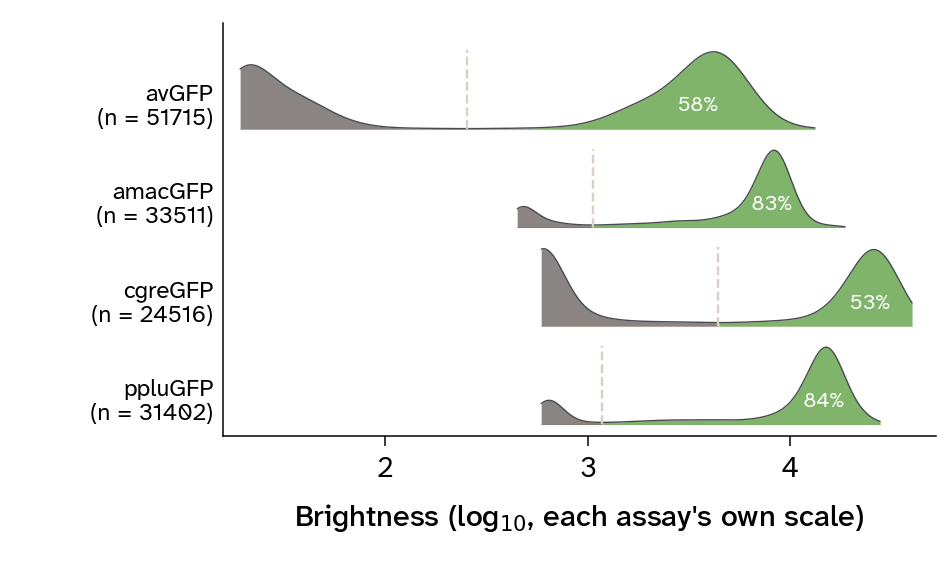

In [4]:
# One density row per scaffold on a shared brightness axis, split at its own cut. The two
# alternative cut rules are computed and printed above but not drawn: three near-coincident rules on
# two of the four rows read as clutter, and the numbers make the point better than the marks did.
# Colour departs from the notebook's Aegean/Amber scheme here for
# one reason: the label being drawn IS green fluorescence, so the functional mass takes an Arcadia
# green and the non-functional pile a dark neutral. Aegean goes back to meaning "the DMS side"
# from Figure 2 onward.
BRIGHT_FILL, BRIGHT_TEXT = GREEN, GREEN_TEXT
DIM_FILL = str(apc.mud)
ROW_H, ROW_GAP = 0.80, 1.02

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.235, right=0.985, bottom=0.235, top=0.96)

for i, sc in enumerate(SCAFFOLDS):
    c = CUTS[sc]
    base = (len(SCAFFOLDS) - 1 - i) * ROW_GAP
    grid = np.linspace(c["x"].min(), c["x"].max(), 400)
    dens = gaussian_kde(c["x"])(grid)
    dens = dens / dens.max() * ROW_H
    dim, bright = grid < c["antimode"], grid >= c["antimode"]
    ax.fill_between(grid[dim], base, base + dens[dim], color=DIM_FILL, alpha=0.75, lw=0, zorder=2)
    ax.fill_between(grid[bright], base, base + dens[bright], color=BRIGHT_FILL, alpha=0.9, lw=0,
                    zorder=2)
    ax.plot(grid, base + dens, color=str(apc.charcoal), lw=0.7, zorder=4)
    ax.plot([c["x"].min(), c["x"].max()], [base] * 2, color=NEUTRAL_SOFT, lw=0.6, zorder=1)
    ax.plot([c["antimode"]] * 2, [base, base + ROW_H * 1.02], color=NEUTRAL_SOFT,
             ls='--', lw=1.2, zorder=5)
    # The one number the row needs, set in white on the functional mass itself: no leader, no
    # value for the cut (the cut is where the fill changes colour, and its number is printed above).
    # At half-column width the functional mode of three of the four scaffolds is only ~40 px across,
    # which fits a percentage and nothing else -- the word "bright" the wide version carried under it
    # ran off the green and became white text on the page, so the caption carries it instead. The
    # label is centred on the width of the peak at its own height rather than on the peak itself,
    # which for a right-skewed mode keeps it clear of the steep flank.
    peak = np.where(bright)[0][np.argmax(dens[bright])]
    y_lab = dens[peak] * 0.30
    lo = hi = peak
    while lo > 0 and dens[lo - 1] >= y_lab:
        lo -= 1
    while hi < len(dens) - 1 and dens[hi + 1] >= y_lab:
        hi += 1
    # Half the panel width means half the pixels per log unit, so the label is set smaller and
    # its centre is clamped inside the axes: three of the four functional modes sit against the
    # right-hand end of their scale, where a centred label would run off the panel.
    ax.annotate(f"{100 * c['bright']:.0f}%", xy=(0.5 * (grid[lo] + grid[hi]), base + y_lab),
                ha="center", va="center", zorder=6,
                **{**NUMBER_NOTE, "fontsize": 11, "color": "white"})

top = (len(SCAFFOLDS) - 1) * ROW_GAP
# "dim" sits in the trough of the top row, the one place on any row with clear ground between the
# non-functional pile and the cut rule.
ax.set_yticks([(len(SCAFFOLDS) - 1 - i) * ROW_GAP for i in range(len(SCAFFOLDS))])
SCAFFOLDS_LABELS = [S+f"\n(n = {CUTS[S]['n']})" for S in SCAFFOLDS]
ax.set_yticklabels(SCAFFOLDS_LABELS,va="bottom",fontsize=12)
ax.set_xlim(1.2, 4.72)   # room at the left for avGFP's variant count, which starts furthest left
ax.set_ylim(-0.12, top + ROW_H + 0.30)
ax.set_xticks([2, 3, 4])      # half the ticks of the wide version: eight labels collide here
ax.set_xlabel("Brightness (log$_{10}$, each assay's own scale)")
apc.mpl.style_plot(ax, monospaced_axes="x")
bare(ax)
ax.tick_params(axis="y", length=0)

fig.savefig(f"{FIGDIR}/brightness_threshold_choice.svg")
fig.savefig(f"{FIGDIR}/brightness_threshold_choice.png", dpi=200)
plt.show()

**Figure 1. Each scaffold's bright/dim cut sits in its own density valley, at a brightness value no
other scaffold shares.** Kernel density of log-brightness for each scaffold's
full processed dataset on a shared axis, each row split at that scaffold's own KDE antimode:
non-functional mass in dark neutral, functional mass in green (the same green Figure 2 gives the
architecture trained on this label), the deployed cut as the full-height
charcoal rule, with the bright fraction it produces set in white on the functional mass; at the left
of each row is that dataset's variant count.

This is the argument for a per-scaffold cut. avGFP's dead pile sits at log10 1.34 and its functional
mode at 3.62, giving a cut at **2.41**; the orthologue assay floors at 2.68-2.81 with functional modes
at 3.92-4.41, giving cuts at **3.03** (amacGFP), **3.64** (cgreGFP) and **3.07** (ppluGFP). Any single
global cut would misclassify a whole scaffold — 2.41 would call essentially every orthologue variant
bright, 3.64 would call most of avGFP dim. Recomputing the antimode reproduces the stored
`brightnessClass` column exactly for all four datasets (58.2 / 83.5 / 52.8 / 83.7% bright), so the
label the sweep trains on is exactly the one this figure draws. The valleys are real minima, not
shoulders: valley density is 0.5-4.4% of peak density.

The exact cut position is not a live worry — the cell above prints the sensitivity: moving a cut
±0.1 log units relabels at most 0.94% of variants (avGFP 0.04%, cgreGFP 0.61%, ppluGFP 0.74%,
amacGFP 0.94%), and ±0.2 units stays under 2.5%. What matters is the *rule*. For avGFP and cgreGFP
the three rules effectively agree (≤0.25% relabelled; their cuts differ by less than 0.07 log units).
For amacGFP and ppluGFP the GMM crossover lands +0.67 and +0.83 log units higher — inside the
functional mode rather than in the valley — relabelling 14.1% and 12.3% of variants and dropping their bright fractions from 83.5% to
69.3% and 83.7% to 71.3%. Those two are the bright-skewed scaffolds (84% bright), i.e. the ones where
a "bright" call carries the least information to begin with; if a later round wants a stricter
functional-brightness label rather than a functional-vs-dead one, those are the two datasets whose
labels would move, and the per-scaffold precision numbers in Section 3's printout are the ones to
re-read afterwards.

## 2. Architecture sweep for the bright/dim classifier

The classifier reads ESM-2 650M per-residue embeddings and predicts one logit for the label
Section 1 defines. The grid is
two backbones — `mlp` (pool only) and `cnn` at depth 1-3 — crossed with six pooling readouts
(`mean`, `max`, `concat`, `concatstd`, `attn`, and the covariance probe `cov`), 24 configurations,
each trained once at seed 0 with BCE-with-logits and `pos_weight` for class imbalance, early-stopped
on validation BCE ([`sweep_classify_parallel.py`](sweep_classify_parallel.py)).

The data is the stratified four-scaffold subsample `sub20k` — 5,000 variants each from avGFP,
amacGFP, cgreGFP and ppluGFP, split per scaffold 70/15/15
([`build_subsample.py`](build_subsample.py)) — so 14,000 train / 3,000 validation / 3,000 test
variants, 69% bright in validation.

Two baselines are pinned alongside the ranking, both fitted on the same 14,000 training variants and
scored on the same 3,000 validation variants:

- **Embedding retrieval**: predict a held-out variant's bright probability as the mean label of its
  *k* nearest training variants in max-pooled ESM-2 space (cosine distance, *k* = 1, 3, 5, 10, 20).
  This is the "does the learned readout beat looking up neighbours" floor.
- **Mutation count**: logistic regression on the number of substitutions from the scaffold's
  wild type plus a scaffold indicator, and nothing else. For DMS brightness this is the baseline
  that matters — brightness falls off steeply with mutational load, so a model can score well by
  counting edits, and any learned readout has to clear that floor before its score means
  anything else.

In [5]:
BACKBONE_LABEL = {"cnn": "CNN", "mlp": "None"}


def load_board(path=f"{SWEEP_DIR}/results.csv"):
    """One row per configuration: architecture/pooling/depth and its val/test metrics."""
    df = pd.read_csv(path).sort_values("val_auroc", ascending=False).reset_index(drop=True)
    df["pretty"] = [f"{BACKBONE_LABEL[a]} ({d}) - {p}" for a, d, p in
                    zip(df["arch"], df["depth"], df["pool"])]
    return df


board = load_board()
DEPLOYED_LABEL = "cnn-max-d2"
rank = int(board.index[board.label == DEPLOYED_LABEL][0]) + 1
best = board.iloc[0]
collapsed = board[board.val_auroc < 0.55]

print(f"{len(board)} configurations | best {best['pretty']} at val AUROC {best.val_auroc:.4f}")
print(f"deployed architecture {DEPLOYED_LABEL} ranks {rank} of {len(board)} "
      f"(val AUROC {float(board.loc[board.label == DEPLOYED_LABEL, 'val_auroc'].iloc[0]):.4f})")
print(f"collapsed to chance ({len(collapsed)}): {', '.join(collapsed.label) or 'none'}")

# The refit that is actually deployed: same architecture, twice the data (sub40k, 10k/scaffold).
import torch  # noqa: E402
_meta = torch.load(DEPLOYED, map_location="cpu", weights_only=False)
REFIT = {k: _meta[k] for k in ("val_auroc", "test_auroc", "val_acc", "test_acc", "n_train",
                               "epoch_best")}
print(f"deployed refit on {REFIT['n_train']:,} train variants: val AUROC {REFIT['val_auroc']:.4f}, "
      f"test AUROC {REFIT['test_auroc']:.4f} @ep{REFIT['epoch_best']}")

24 configurations | best CNN (2) - concatstd at val AUROC 0.9609
deployed architecture cnn-max-d2 ranks 3 of 24 (val AUROC 0.9595)
collapsed to chance (2): cnn-cov-d3, cnn-cov-d2


deployed refit on 28,000 train variants: val AUROC 0.9816, test AUROC 0.9809 @ep34


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

K_SWEEP = [1, 3, 5, 10, 20]
POOLED_NPY = f"{DMS}/sub20k_maxpool.npy"    # analysis cache, git-ignored like the rest of DMS_data/


def sub20k_maxpool(path=POOLED_NPY):
    """Max-pooled ESM-2 embedding per sub20k variant, cached.

    The sweep's own cache is the (20000, 237, 1280) fp16 per-residue array -- 12 GB, more than this
    machine's RAM once anything else is loaded -- so pool it in blocks straight off the memmap and
    keep only the (20000, 1280) result. Max pooling is used because that is the readout the
    deployed model learns on top of; the retrieval floor should see the same summary.
    """
    if os.path.exists(path):
        return np.load(path)
    H = np.load(f"{DMS}/sub20k_esm_residue_fp16.npy", mmap_mode="r")
    Ls = np.load(f"{DMS}/sub20k_esm_residue_len.npy").astype(int)
    out = np.empty((len(H), H.shape[2]), np.float32)
    for i in range(0, len(H), 200):
        blk = np.asarray(H[i:i + 200]).astype(np.float32)
        for j in range(len(blk)):
            out[i + j] = blk[j, :Ls[i + j]].max(0)
    np.save(path, out)
    return out


def mutation_load(rows, seq_col="mutatedSequence"):
    """Substitutions from each scaffold's wild type.

    The processed DMS tables carry only the mutated full-length sequence, so the wild type is
    recovered as the scaffold's per-position consensus: these libraries average ~3 substitutions
    in 235-239 positions, so the modal residue at every position is the parent by a wide margin.
    """
    n_mut = np.zeros(len(rows), int)
    for _, g in rows.groupby("scaffold"):
        arr = np.array([list(s) for s in g[seq_col]])
        wt = np.array([pd.Series(arr[:, j]).mode()[0] for j in range(arr.shape[1])])
        n_mut[g.index.to_numpy()] = (arr != wt[None, :]).sum(1)
    return n_mut


rows20 = pd.read_csv(f"{DMS}/sub20k_sequences.csv")
y20 = rows20.label.to_numpy()
tr20 = np.where(rows20.split == "train")[0]
va20 = np.where(rows20.split == "val")[0]
X20 = sub20k_maxpool()
NMUT20 = mutation_load(rows20)

nulls = {}
for k in K_SWEEP:
    nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X20[tr20])
    idx = nn.kneighbors(X20[va20], return_distance=False)
    nulls[f"NN k={k}"] = roc_auc_score(y20[va20], y20[tr20][idx].mean(1))

Xn = np.column_stack([NMUT20, pd.get_dummies(rows20.scaffold).to_numpy().astype(float)])
lr = LogisticRegression(max_iter=1000).fit(Xn[tr20], y20[tr20])
nulls["Edit count"] = roc_auc_score(y20[va20], lr.predict_proba(Xn[va20])[:, 1])

best_null = max(nulls.values())
for lab, v in nulls.items():
    print(f"  {lab:10} val AUROC {v:.4f}")
print(f"best baseline {best_null:.4f} | configurations above it: "
      f"{int((board.val_auroc > best_null).sum())} of {len(board)}")
print(f"train/val bright prevalence {y20[tr20].mean():.3f} / {y20[va20].mean():.3f}; "
      f"median edit load {np.median(NMUT20):.0f} substitutions")

  NN k=1     val AUROC 0.6444
  NN k=3     val AUROC 0.7161
  NN k=5     val AUROC 0.7409
  NN k=10    val AUROC 0.7630
  NN k=20    val AUROC 0.7739
  Edit count val AUROC 0.7690
best baseline 0.7739 | configurations above it: 18 of 24
train/val bright prevalence 0.697 / 0.690; median edit load 3 substitutions


In [7]:
# Is the top of the leaderboard a real ordering? Only 3,000 validation variants separate the top
# configurations, so their logits are rescored here and the AUROC differences bootstrapped over
# variants (paired: the same resampled variants for every configuration). This is what makes the
# selection statement in the caption an honest one rather than "we took the argmax".
from fpdesign import peak_models as pm  # noqa: E402

TOP5 = board.label.head(5).tolist()
BOOT_NPZ = f"{SWEEP_DIR}/val_logits_top5.npz"
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def val_logits(labels=TOP5, path=BOOT_NPZ):
    """Validation logits per configuration, cached. Reads only the 3,000 validation rows."""
    if os.path.exists(path):
        z = np.load(path)
        return {lab: z[lab] for lab in labels}
    H = np.load(f"{DMS}/sub20k_esm_residue_fp16.npy", mmap_mode="r")
    Ls = np.load(f"{DMS}/sub20k_esm_residue_len.npy").astype(int)
    ar = torch.arange(H.shape[1])
    out = {}
    for lab in labels:
        net, _ = pm.load_model(f"{SWEEP_DIR}/{lab}_s0.pt", dev, out=1)
        net.eval()
        chunks = []
        with torch.no_grad():
            for i in range(0, len(va20), 128):
                b = va20[i:i + 128]
                Hb = torch.from_numpy(np.asarray(H[b])).float().to(dev)
                mk = (ar.unsqueeze(0) < torch.tensor(Ls[b]).unsqueeze(1)).to(dev)
                chunks.append(net(Hb, mk).cpu().numpy().ravel())
        out[lab] = np.concatenate(chunks)
    np.savez(path, **out)
    return out


VL = val_logits()
yv = y20[va20]
rng = np.random.default_rng(RNG_SEED)
BOOT = 2000
draws = rng.integers(0, len(yv), (BOOT, len(yv)))
boot = {lab: np.array([roc_auc_score(yv[d], VL[lab][d]) for d in draws]) for lab in TOP5}
point = {lab: roc_auc_score(yv, VL[lab]) for lab in TOP5}

for lab in TOP5:
    print(f"  {lab:18} AUROC {point[lab]:.4f}  bootstrap 95% "
          f"[{np.percentile(boot[lab], 2.5):.4f}, {np.percentile(boot[lab], 97.5):.4f}]")
print()
for lab in TOP5:
    if lab == DEPLOYED_LABEL:
        continue
    d = boot[lab] - boot[DEPLOYED_LABEL]
    print(f"  {lab:18} minus {DEPLOYED_LABEL}: {point[lab] - point[DEPLOYED_LABEL]:+.4f}  "
          f"95% [{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  "
          f"P(better) = {np.mean(d > 0):.2f}")

  cnn-concatstd-d2   AUROC 0.9609  bootstrap 95% [0.9536, 0.9682]
  cnn-concat-d2      AUROC 0.9601  bootstrap 95% [0.9525, 0.9679]
  cnn-max-d2         AUROC 0.9595  bootstrap 95% [0.9517, 0.9670]
  cnn-max-d1         AUROC 0.9532  bootstrap 95% [0.9450, 0.9611]
  cnn-concatstd-d1   AUROC 0.9489  bootstrap 95% [0.9401, 0.9575]

  cnn-concatstd-d2   minus cnn-max-d2: +0.0014  95% [-0.0057, +0.0086]  P(better) = 0.66
  cnn-concat-d2      minus cnn-max-d2: +0.0006  95% [-0.0067, +0.0080]  P(better) = 0.59
  cnn-max-d1         minus cnn-max-d2: -0.0064  95% [-0.0140, +0.0015]  P(better) = 0.06
  cnn-concatstd-d1   minus cnn-max-d2: -0.0106  95% [-0.0188, -0.0018]  P(better) = 0.01


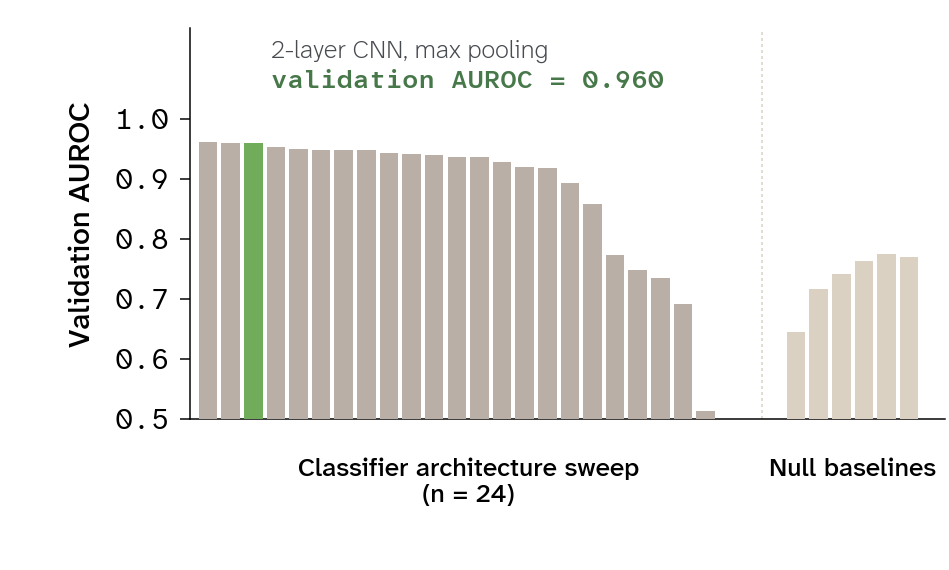

In [8]:
# The deployed architecture in GREEN; every other configuration and every baseline recedes into
# neutral tones, per the guide's "one series emphasized, the rest recede" pattern. The y-axis starts
# at 0.5 because that is the floor of the metric -- a bar drawn from 0 to chance carries no
# information -- which is also why the two collapsed configurations have no visible bar.
ranked = board.reset_index(drop=True)
null_items = list(nulls.items())
GAP = 2.0
x_cfg = np.arange(len(ranked))
x_null = np.arange(len(null_items)) + len(ranked) + GAP
hi = int(ranked.index[ranked.label == DEPLOYED_LABEL][0])
bar_color = [GREEN if i == hi else NEUTRAL for i in range(len(ranked))]
FLOOR = 0.5

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.20, right=0.995, top=0.95, bottom=0.265)

ax.bar(x_cfg, ranked.val_auroc - FLOOR, bottom=FLOOR, color=bar_color, width=0.82,
       edgecolor="none", zorder=3)
ax.bar(x_null, [v - FLOOR for _, v in null_items], bottom=FLOOR, color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
ax.axvline(len(ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# The callout is the configuration that was selected and the number it was selected on: its own
# validation AUROC, the height of the green bar. The deployed checkpoint is this architecture
# refit on twice the data -- a different number, on a different split, which the caption carries
# rather than a label sitting next to a bar it does not describe.

deployed_auroc = float(ranked.loc[hi, "val_auroc"])
ax.annotate("2-layer CNN, max pooling", xy=(hi + 0.8, 1.112), xycoords="data",
            ha="left", va="center", **{**ANNOTATION, "fontsize": 13})
ax.annotate(f"validation AUROC = {deployed_auroc:.3f}", xy=(hi + 0.8, 1.062), xycoords="data",
            ha="left", va="center",
            **{**NUMBER_NOTE, "fontsize": 13, "fontweight": "semibold", "color": GREEN_TEXT})

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.6)
ax.set_ylim(FLOOR, 1.15)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_ylabel("Validation AUROC")

# At this width the two x-axis group labels are what sets the bottom margin, so they run at
# 13 pt: the wide version's 15 pt made the longer one overrun its own group of bars.
group_style = {**label_style, "fontsize": 13}
ax.text(x_cfg.mean(), -0.10, "Classifier architecture sweep\n(n = 24)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **group_style)
ax.text(x_null.mean(), -0.10, "Null baselines",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **group_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
bare(ax)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/brightness_sweep_auroc.svg")
fig.savefig(f"{FIGDIR}/brightness_sweep_auroc.png", dpi=200)
plt.show()

**Figure 2. The pooling readout barely matters at the top of the sweep, so the deployed
architecture was picked from a three-way tie — but every learned configuration that trained at all
clears the retrieval and edit-count baselines by a wide margin.** Validation AUROC for all 24
backbone x pooling x depth configurations of the bright/dim classifier (single seed, per-scaffold
70/15/15 split of the 20,000-variant four-scaffold subsample), ranked left to right, against
embedding-retrieval baselines (cosine *k*-NN over max-pooled ESM-2, *k* = 1-20) and a logistic
regression on edit count plus scaffold identity. The deployed architecture, CNN (2) - max, is in
green -- the colour this notebook reserves for the bright class and for the model that predicts it;
the short rule above it is the same architecture refit on the 40,000-variant subsample,
which is the checkpoint the campaign actually loads. The axis starts at 0.5 because that is chance
for AUROC.

`cnn-max-d2` ranks **third** on this leaderboard, behind `cnn-concatstd-d2` (0.9609) and
`cnn-concat-d2` (0.9601) at 0.9595 — and the paired bootstrap over the 3,000 validation variants
says that ordering is not real: the AUROC difference to either configuration above it has a 95%
interval straddling zero ([-0.006, +0.009] and [-0.007, +0.008]), with P(better) of 0.66 and 0.59.
The two configurations *below* it separate more cleanly (`cnn-max-d1` at P = 0.06,
`cnn-concatstd-d1` at P = 0.01), so what the sweep establishes is a top group of three, not a
winner. Within that group the choice went to max pooling because it is the cheapest readout of the
three (one vector per residue channel, no concatenated statistics) and because it is the same
readout the peak surrogate uses, so a design run holds one pooling convention end to end.

Depth and pooling behave as they do on the peak sweeps: CNNs beat the pool-only MLPs everywhere
(0.918-0.961 vs 0.691-0.893), depth 2 is the sweet spot, and the covariance probe is the one
unstable member of the grid — competitive at depth 1 (0.947) but the *only* thing in the sweep that
fails to train at all, with `cnn-cov-d2` and `cnn-cov-d3` both collapsing to a single class
(AUROC 0.500 and 0.513, F1 = 0.000, no epoch survived early stopping). Doubling the training data
for the refit moves validation AUROC from 0.960 to 0.982 and accuracy from 0.903 to 0.943, which is
the only reason a second training run was worth doing.

The baselines are worth reading as a pair. Retrieval over the same embedding tops out at 0.774
(*k* = 20) and edit count plus scaffold reaches 0.769 — so ESM-2 neighbourhoods and "how many
mutations does it carry" are about equally informative, and the learned readout adds ~0.19 AUROC on
top of either. Eighteen of 24 configurations clear the strongest baseline; the six that do not are
the two collapsed covariance fits and the four weakest pool-only MLPs (`mlp-mean` 0.773 through
`mlp-concatstd` 0.691), which is a statement about pooling without a convolution, not about the
architecture family that got deployed — every CNN in the grid that trained at all beats every
baseline.

## 3. What the campaign asks of this classifier, and which metrics answer it

Figure 2's numbers are the sweep's own: AUROC over a held-out sample of the same DMS libraries the
model trained on. That is the right metric for *choosing an architecture* and the wrong one for
*deciding how much to trust a shortlist*, because the campaign's question differs from the sweep's
in four specific ways.

| The campaign does this | So the metric should be |
|---|---|
| Thresholds the logit — `logit > 0` reported as `is_bright`, `logit > 0.5` to enter a shortlist pool — and never ranks DMS variants | **Precision at those two thresholds** (printed below) and **where they sit on the ROC**, not AUROC over the whole score range — Section 4 |
| Admits a design when its ESM-2 max-pool NN distance to the 40k DMS cloud is inside the cloud's own 99th percentile | **Precision inside that same distance stratum**, which is the sparsest corner of the training distribution — Section 5 |
| Applies **one** threshold everywhere, to designs that sit in the sparsest strata | **TPR and FPR per stratum** (a ROC per stratum), which separates the classifier degrading from the population getting harder — Section 6 |
| Spends 10 wet-lab wells per strategy on designs whose true bright rate nobody knows | **Expected yield as a function of the assumed prior**, driven by the measured likelihood ratio rather than by DMS prevalence — Section 7 |

Two things follow from the table that are worth stating before any of the figures.

**Aggregate AUROC and accuracy are dominated by variants the campaign will never see.** Two thirds
of held-out variants are scored with |logit| > 4 — the model is certain, and it is right — while
the slab between the campaign's two thresholds (`logit` 0 to 0.5) holds 1.1% of them. A metric
averaged over the whole test set is therefore mostly a report on easy variants.

**Precision, not accuracy, is the currency.** The campaign discards candidates by the thousand
(2,058 DMS-guided and 5,448 MSA-guided designs, of which a quarter clear the ID-and-bright gate), so
recall costs nothing: a missed bright design is one of many, while a shortlisted dim design is a
wasted well. Every number below that could be quoted either way is quoted as precision.

Sections 4-7 read the deployed checkpoint's per-variant held-out predictions from
[`figures/nn_distance_accuracy_per_row.csv`](figures/nn_distance_accuracy_per_row.csv)
(written by [`nn_distance_accuracy.py`](nn_distance_accuracy.py), which scores all 40,000 sub40k
variants with `trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt`), and use the **test** split only —
1,500 variants per scaffold, never touched by training or early stopping.

Every number binned by distance from the DMS cloud is the exception — Figure 3's inset and all of
Sections 5 and 6. Those strata are slices of the distance axis a hundred times thinner than the
split can support, so they are measured on **every** processed variant the checkpoint never learned
from — 97,499 of them, the whole four-scaffold corpus minus both subsamples' train and validation
rows. The second cell below scores that pool once and caches it, and defines the strata every one
of those figures bins by; it needs no new embeddings, and it says how.

In [9]:
# The deployed model's held-out predictions, plus the two axes the campaign cares about: how far a
# variant sits from its wild type (edit load) and how far it sits from the DMS cloud (NN distance,
# already computed per row by nn_distance_accuracy.py in the same z-scored max-pool space the
# campaign's in-distribution gate uses).
pr = pd.read_csv(PER_ROW)
rows40 = pd.read_csv(f"{DMS}/sub40k_sequences.csv")
assert (pr.scaffold.values == rows40.scaffold.values).all() and (pr.y.values == rows40.label.values).all(), \
    "nn_distance_accuracy_per_row.csv is not row-aligned with sub40k_sequences.csv -- rerun the script"

held = pr.assign(n_mut=mutation_load(rows40), logit=np.log(pr.prob / (1 - pr.prob)))
te = held[held.split == "test"].reset_index(drop=True)
ID_CUT = json.load(open("figures/nn_distance_accuracy_meta.json"))["id_cutoff_p99"]

# The campaign's two thresholds, from make_shortlist_case.py: the model's own decision boundary and
# the stricter bar a design must clear to enter a shortlist pool.
THR_MODEL, THR_SHORTLIST = 0.0, 0.5


def gate(g, thr=THR_SHORTLIST):
    """What the campaign's gate does to a set of variants, in the campaign's own terms."""
    keep = g.logit > thr
    y = g.y == 1
    tp, fp = int((keep & y).sum()), int((keep & ~y).sum())
    tpr = (keep & y).sum() / max(y.sum(), 1)
    fpr = (keep & ~y).sum() / max((~y).sum(), 1)
    return dict(n=len(g), prevalence=y.mean(), kept=keep.mean(), n_kept=tp + fp,
                precision=tp / max(tp + fp, 1), recall=tpr, fpr=fpr,
                lr_plus=tpr / max(fpr, 1e-9),
                auroc=roc_auc_score(g.y, g.prob) if 0 < g.y.sum() < len(g) else np.nan)


def wilson(k, n, z=1.96):
    """Wilson score interval -- the distance strata in Sections 5-6 get down to tens of variants."""
    if n == 0:
        return (np.nan, np.nan)
    p, d = k / n, 1 + z * z / n
    c = p + z * z / (2 * n)
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((c - h) / d, (c + h) / d)


# The band the campaign actually operates in: the brightness logits of the designs that were
# shortlisted for the wet lab, read back out of the shortlist workbooks rather than assumed. Only
# the two brightness-guided strategies are gated on the classifier, so only their four workbooks
# (two targets each) carry a logit that was used as a filter.
SHORTLIST_FILES = [f"{CAMP}/shortlists/shortlist_{t}_{s}-guide.xlsx"
                   for t in ("EBFP", "mOrange") for s in ("DMS", "MSA")]
shortlisted = pd.concat([pd.read_excel(f) for f in SHORTLIST_FILES], ignore_index=True)
shortlisted = shortlisted[shortlisted.role == "design"]
SHORT_LOGIT = shortlisted.bright_logit.astype(float).to_numpy()
SHORT_LO, SHORT_HI = float(SHORT_LOGIT.min()), float(SHORT_LOGIT.max())
SHORT_MUT = shortlisted.n_mut_vs_EGFP.astype(float).to_numpy()

print(f"test split: {len(te):,} variants, {te.y.mean():.1%} bright, "
      f"AUROC {roc_auc_score(te.y, te.prob):.4f}, accuracy at logit>0 "
      f"{((te.logit > 0).astype(int) == te.y).mean():.3f}")
print(f"|logit| > 4: {(te.logit.abs() > 4).mean():.1%} of test variants | "
      f"logit in [0, 0.5]: {((te.logit >= 0) & (te.logit <= 0.5)).mean():.1%}")
print()
for thr in (THR_MODEL, THR_SHORTLIST):
    m = gate(te, thr)
    print(f"logit > {thr:+.1f} (p > {1 / (1 + np.exp(-thr)):.3f}): keeps {m['kept']:.1%} of variants, "
          f"precision {m['precision']:.4f}, recall {m['recall']:.3f}, LR+ {m['lr_plus']:.1f}")
print()
print(f"{'scaffold':10} {'n':>5} {'bright':>7} {'AUROC':>7} {'prec@0':>8} {'prec@0.5':>9}")
for s, g in te.groupby("scaffold"):
    print(f"{s:10} {len(g):5d} {g.y.mean():7.3f} {gate(g)['auroc']:7.4f} "
          f"{gate(g, THR_MODEL)['precision']:8.4f} {gate(g, THR_SHORTLIST)['precision']:9.4f}")
print()
tr40 = held[held.split == "train"]
pw = (1 - tr40.y.mean()) / tr40.y.mean()
print(f"training pos_weight = (1-prev)/prev = {pw:.3f}, i.e. every logit is shifted by "
      f"log(pos_weight) = {np.log(pw):+.3f} relative to a prevalence-calibrated model; "
      f"mean predicted probability {te.prob.mean():.4f} vs observed prevalence {te.y.mean():.4f}")
print()
print(f"{len(SHORT_LOGIT)} shortlisted designs: logit {SHORT_LO:.2f} to {SHORT_HI:.2f} "
      f"(median {np.median(SHORT_LOGIT):.2f}), {int(SHORT_MUT.min())}-{int(SHORT_MUT.max())} "
      f"substitutions from EGFP (median {np.median(SHORT_MUT):.0f})")

test split: 6,000 variants, 69.8% bright, AUROC 0.9809, accuracy at logit>0 0.938
|logit| > 4: 66.6% of test variants | logit in [0, 0.5]: 1.1%

logit > +0.0 (p > 0.500): keeps 68.2% of variants, precision 0.9660, recall 0.945, LR+ 12.3
logit > +0.5 (p > 0.622): keeps 67.0% of variants, precision 0.9709, recall 0.933, LR+ 14.5

scaffold       n  bright   AUROC   prec@0  prec@0.5
amacGFP     1500   0.842  0.9741   0.9692    0.9721
avGFP       1500   0.600  0.9862   0.9592    0.9677
cgreGFP     1500   0.511  0.9721   0.9553    0.9578
ppluGFP     1500   0.837  0.9820   0.9736    0.9790

training pos_weight = (1-prev)/prev = 0.435, i.e. every logit is shifted by log(pos_weight) = -0.832 relative to a prevalence-calibrated model; mean predicted probability 0.6763 vs observed prevalence 0.6975

40 shortlisted designs: logit 0.60 to 4.22 (median 1.35), 6-14 substitutions from EGFP (median 10)


In [10]:
# Every processed DMS variant the deployed checkpoint never learned from, scored once and cached.
#
# Why a second held-out population at all: every distance-conditioned number below -- the Figure 3
# inset, Figure 4's likelihood ratios, Figure 5's precision bars, Figure 6's per-stratum curves --
# is measured inside strata that
# hold about 1% of the reference cloud each. On the 6,000-row test split that left 51 variants in
# the 98-99 band, of which 11 were called bright, i.e. a precision with a +/-20-point interval. So
# those sections evaluate on the whole processed corpus minus everything the model was fitted or
# selected on: 141,144 variants across the four scaffolds, minus every row in the train or validation
# split of either subsample -- sub40k, which trained the deployed checkpoint, and sub20k, which chose
# its architecture. The remainder includes both subsamples' test rows and the ~100k variants that were
# never sampled into either.
#
# Nothing has to be re-embedded: the per-residue ESM-2 caches for both source tables already exist
# (31 GB + 54 GB), so the pass streams them block by block, runs the classifier head, and max-pools
# the same vectors the in-distribution test needs. It is I/O-bound at roughly ten minutes, so its
# output -- label, logit, distance and edit load per variant -- is cached in DMS_data/ under a
# signature naming the checkpoint and the exclusion set, and rebuilt only if either changes.
from concurrent.futures import ThreadPoolExecutor  # noqa: E402
import time  # noqa: E402

HELDOUT_NPZ = f"{DMS}/heldout_scored.npz"
POOL_SOURCES = [("avgfp_dms_sequences.csv", "esm_residue_fp16.npy", "esm_residue_len.npy"),
                ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy",
                 "ortho_gfp_dms_esm_residue_len.npy")]
POOL_COLS = ("scaffold", "y", "logit", "nn_dist", "n_mut", "src", "src_row")

# The in-distribution reference: the same 40k max-pool cloud, z-scoring and cut the campaign uses.
# Defined here because both this section's held-out pool and the design distances below need it.
ref = np.load(f"{DMS}/esm_maxpool_4scaffold_10k.npz", allow_pickle=True)
MP = ref["mp"]
mu, sd = MP.mean(0), MP.std(0) + 1e-6
Zref = torch.as_tensor((MP - mu) / sd, dtype=torch.float32, device=dev)


def _fitted_on():
    """{(src, src_row)} for every row either subsample used to fit or to select -- what to exclude."""
    ex = set()
    for stem in ("sub20k", "sub40k"):
        df = pd.read_csv(f"{DMS}/{stem}_sequences.csv")
        m = df.split.isin(("train", "val"))
        ex |= set(zip(df.src[m], df.src_row[m]))
    return ex


def score_heldout_pool(path=HELDOUT_NPZ, block=1024):
    """Score every never-fitted DMS variant with the deployed checkpoint; cached to `path`.

    Returns a frame with one row per variant: scaffold, label, logit, 1-NN distance to the 40k
    reference cloud (self-excluded for the 40k rows that are themselves in it) and edit load.
    """
    excluded = _fitted_on()
    signature = f"{os.path.basename(DEPLOYED)}|{len(excluded)}"
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        if str(z["signature"]) == signature:
            print(f"loaded cached scores for {len(z['y']):,} held-out variants ({path})")
            return pd.DataFrame({c: z[c] for c in POOL_COLS})
        print("cache signature does not match the current checkpoint/exclusion set -- rescoring")

    net, _ = pm.load_model(DEPLOYED, dev, out=1)
    net.eval()
    # Row of the reference cloud a variant occupies, if any, so it can be excluded from its own
    # nearest-neighbour search (the cloud is row-aligned with sub40k).
    s40 = pd.read_csv(f"{DMS}/sub40k_sequences.csv")
    cloud_row = {(a, b): i for i, (a, b) in enumerate(zip(s40.src, s40.src_row))}

    frames, t0 = [], time.time()
    for csv_name, emb_name, len_name in POOL_SOURCES:
        table = pd.read_csv(f"{DMS}/{csv_name}")
        table["n_mut"] = mutation_load(table)
        H = np.load(f"{DMS}/{emb_name}", mmap_mode="r")
        Ls = np.load(f"{DMS}/{len_name}").astype(int)
        assert len(H) == len(table), f"{emb_name} is not row-aligned with {csv_name}"
        rows = np.array([i for i in range(len(table)) if (emb_name, i) not in excluded])
        ar = torch.arange(H.shape[1], device=dev)
        starts = list(range(0, len(rows), block))
        print(f"{csv_name}: {len(rows):,} of {len(table):,} rows held out, "
              f"{len(rows) * H.shape[1] * H.shape[2] * 2 / 1e9:.0f} GB to stream", flush=True)

        def read(k):
            idx = rows[starts[k]:starts[k] + block]
            return idx, np.array(H[idx])

        logits, dists = [], []
        with ThreadPoolExecutor(1) as pool_io, torch.no_grad():
            future = pool_io.submit(read, 0)
            for k in range(len(starts)):
                idx, arr = future.result()
                if k + 1 < len(starts):
                    future = pool_io.submit(read, k + 1)          # read ahead while the GPU works
                Hb = torch.from_numpy(arr).to(dev).float()
                mk = ar.unsqueeze(0) < torch.as_tensor(Ls[idx], device=dev).unsqueeze(1)
                logits.append(net(Hb, mk).float().cpu().numpy().ravel())
                E = (pm.masked_pool(Hb, mk, "max").float()
                     - torch.as_tensor(mu, dtype=torch.float32, device=dev)) \
                    / torch.as_tensor(sd, dtype=torch.float32, device=dev)
                D = torch.cdist(E, Zref)
                for local, r in enumerate(idx):                   # a variant is not its own neighbour
                    ci = cloud_row.get((emb_name, int(r)))
                    if ci is not None:
                        D[local, ci] = float("inf")
                dists.append(D.min(dim=1).values.cpu().numpy())
                if k % 20 == 0 or k == len(starts) - 1:
                    done = min(starts[k] + block, len(rows))
                    print(f"  {done:>7,}/{len(rows):,}  {time.time() - t0:6.0f}s", flush=True)
        sub = table.iloc[rows]
        frames.append(pd.DataFrame(dict(
            scaffold=sub.scaffold.to_numpy(), y=(sub.brightnessClass == "bright").astype(int).to_numpy(),
            logit=np.concatenate(logits), nn_dist=np.concatenate(dists),
            n_mut=sub.n_mut.to_numpy(), src=emb_name, src_row=rows)))

    out = pd.concat(frames, ignore_index=True)
    np.savez_compressed(path, signature=np.array(signature), **{c: out[c].to_numpy() for c in POOL_COLS})
    print(f"scored {len(out):,} held-out variants in {(time.time() - t0) / 60:.1f} min -> {path}")
    return out


pool = score_heldout_pool()
pool["prob"] = 1.0 / (1.0 + np.exp(-pool.logit))     # `gate()` reports AUROC off the probability
print(f"\nheld-out pool: {len(pool):,} variants ({len(pool) / 141144:.0%} of the processed corpus), "
      f"{pool.y.mean():.1%} bright")
print(pool.groupby("scaffold").agg(n=("y", "size"), bright=("y", "mean"),
                                   median_dist=("nn_dist", "median")).round(3).to_string())
# The strata every distance-conditioned figure uses: percentiles of the REFERENCE CLOUD's own
# self-neighbour distances -- the campaign's statistic, unchanged -- with one colour per stratum,
# light to dark with increasing distance, shared by the Figure 3 inset and by Figures 4 and 6.
# The last bin is open-ended: a held-out variant can sit further out than any of the cloud's 40k rows.
PCTS = [0, 50, 90, 95, 98, 99, 100]
EDGES = np.percentile(held.nn_dist, PCTS)
EDGES[-1] = np.inf
STRAT_LABELS = [f"{PCTS[i]}+" if not np.isfinite(EDGES[i + 1]) else f"{PCTS[i]}-{PCTS[i + 1]}"
                for i in range(len(PCTS) - 1)]
STRAT_C = [apc.gradients.blues.to_mpl_cmap()(v)          # apc gradients run dark -> light
           for v in np.linspace(0.78, 0.0, len(STRAT_LABELS))]

print("\nagainst the 6,000-row test split the other sections use:")
print(f"  pooled AUROC {roc_auc_score(pool.y, pool.logit):.4f} vs test-split AUROC "
      f"{roc_auc_score(te.y, te.prob):.4f}; precision at logit>0.5 "
      f"{gate(pool, THR_SHORTLIST)['precision']:.4f} vs {gate(te, THR_SHORTLIST)['precision']:.4f}")

loaded cached scores for 97,499 held-out variants (DMS_data/heldout_scored.npz)

held-out pool: 97,499 variants (69% of the processed corpus), 68.2% bright
              n  bright  median_dist
scaffold                            
amacGFP   21853   0.834    10.336000
avGFP     42623   0.582    16.815001
cgreGFP   13197   0.523     7.584000
ppluGFP   19826   0.836     9.728000

against the 6,000-row test split the other sections use:
  pooled AUROC 0.9837 vs test-split AUROC 0.9809; precision at logit>0.5 0.9706 vs 0.9709


## 4. Metric 1 — the two thresholds in ROC space, and the multiplier they buy

Precision at a fixed threshold — 96.6% at the model boundary, 97.1% at the shortlist bar, both
printed above — is what a wet-lab slot cares about, and it is also what makes those numbers
untransportable: precision depends on the population's bright rate, and the design pool's is unknown.
The ROC is the same pair of thresholds with the prevalence divided out — true-positive rate against
false-positive rate — so populations with different bright rates can be compared on it directly,
and the campaign's two thresholds become two points on a curve.

The quantity to read off a ROC here is not the area. It is the **slope of the ray from the origin
through an operating point**, which is the positive likelihood ratio LR+ = TPR / FPR — the factor the
classifier multiplies the odds of "bright" by when it says bright, and the one number that survives
the move from DMS variants to designs (Section 7 turns it into an expected wet-lab yield). The curve
is the pooled held-out test split; the design-matched stratum of variants carrying at least five
substitutions is computed alongside it and printed, since its likelihood ratio is the one Section 7
carries, but it is not drawn — its curve lies on top of the pooled one, and what differs between
them is a number rather than a shape.

One thing an aggregate ROC cannot say is whether that discrimination survives away from the DMS
cloud, which is where the designs are. The inset answers it in one number per stratum — the same
strata, on the same never-fitted pool, that Figure 6 draws as full curves.

In [11]:
from sklearn.metrics import roc_curve  # noqa: E402

# Both populations are computed and printed -- they are the two likelihood ratios Section 7 carries
# -- but only the pooled one is drawn: the >= 5-substitution curve sits on top of it (the areas
# differ by 0.003) and the quantity that separates them, LR+, is not visible as a separation.
ROC_POPS = [("All held-out variants", te, NEUTRAL),
            ("Variants >= 5 substitutions", te[te.n_mut >= 5], HIGHLIGHT)]
DRAWN = "All held-out variants"
# The campaign's own bar gets the larger marker; the model boundary is the smaller one.
THR_MARKER = {THR_MODEL: "o", THR_SHORTLIST: "^"}
THR_SIZE = {THR_MODEL: 34, THR_SHORTLIST: 130}

ROC = {}
for name, g, color in ROC_POPS:
    fpr, tpr, _ = roc_curve(g.y, g.prob)
    ROC[name] = dict(fpr=fpr, tpr=tpr, auroc=roc_auc_score(g.y, g.prob), color=color,
                     points={t: gate(g, t) for t in (THR_MODEL, THR_SHORTLIST)}, n=len(g),
                     prevalence=float(g.y.mean()))

for name, r in ROC.items():
    print(f"{name:28} n={r['n']:5d} bright {r['prevalence']:.3f} AUROC {r['auroc']:.4f}")
    for t, m in r["points"].items():
        print(f"{'':28}   logit > {t:+.1f}: TPR {m['recall']:.4f}  FPR {m['fpr']:.4f}  "
              f"LR+ {m['lr_plus']:5.1f}  precision {m['precision']:.4f}")
lo, hi = [ROC[n]["points"][THR_SHORTLIST]["lr_plus"] for n, _, _ in ROC_POPS]
d_auroc = abs(ROC[ROC_POPS[0][0]]["auroc"] - ROC[ROC_POPS[1][0]]["auroc"])
print(f"\nAUROC differs by {d_auroc:.4f} between the two populations; LR+ at the shortlist bar "
      f"differs by {hi / lo:.1f}x ({lo:.1f} -> {hi:.1f})")

# The inset: the drawn curve's own area, and then the same classifier's AUROC inside each distance
# stratum on the never-fitted pool of Section 3. Figure 6 draws those strata as full ROC curves;
# this is the one-number-per-stratum version, put next to the aggregate it qualifies. The first
# entry is the unstratified test split -- the curve in the panel -- so the inset says what the
# aggregate is before it says what distance does to it.
r_all = ROC[DRAWN]          # the curve the panel draws; its area is the inset's first bar
STRAT_AUROC = []
for i, lab in enumerate(STRAT_LABELS):
    g = pool[(pool.nn_dist >= EDGES[i]) & (pool.nn_dist < EDGES[i + 1])]
    STRAT_AUROC.append(dict(label=lab, auroc=roc_auc_score(g.y, g.logit), n=len(g),
                            prevalence=float(g.y.mean())))
ALL_AUROC = dict(label="All", auroc=r_all["auroc"], n=r_all["n"], prevalence=r_all["prevalence"])
INSET_BARS = [ALL_AUROC] + STRAT_AUROC
print("\nAUROC unstratified (the drawn test-split curve) and by cloud-distance stratum on the")
print("97,499 never-fitted variants (the Figure 6 strata):")
print("  " + "  ".join(f"{s['label']:>7}" for s in INSET_BARS))
print("  " + "  ".join(f"{s['auroc']:7.3f}" for s in INSET_BARS))
print("  " + "  ".join(f"{s['n']:7,d}" for s in INSET_BARS) + "   variants")
print(f"  the wide pool unstratified is {roc_auc_score(pool.y, pool.logit):.3f}, so the "
      "leftmost bar is not an easier population than the six")

All held-out variants        n= 6000 bright 0.698 AUROC 0.9809
                               logit > +0.0: TPR 0.9446  FPR 0.0766  LR+  12.3  precision 0.9660
                               logit > +0.5: TPR 0.9333  FPR 0.0645  LR+  14.5  precision 0.9709
Variants >= 5 substitutions  n=  914 bright 0.299 AUROC 0.9784
                               logit > +0.0: TPR 0.8608  FPR 0.0343  LR+  25.1  precision 0.9144
                               logit > +0.5: TPR 0.8498  FPR 0.0265  LR+  32.0  precision 0.9317

AUROC differs by 0.0025 between the two populations; LR+ at the shortlist bar differs by 2.2x (14.5 -> 32.0)

AUROC unstratified (the drawn test-split curve) and by cloud-distance stratum on the
97,499 never-fitted variants (the Figure 6 strata):
      All     0-50    50-90    90-95    95-98    98-99      99+
    0.981    0.983    0.979    0.974    0.968    0.950    0.957
    6,000   32,030   35,154    5,846    3,835    1,379    1,120   variants
  the wide pool unstratified is 0.9

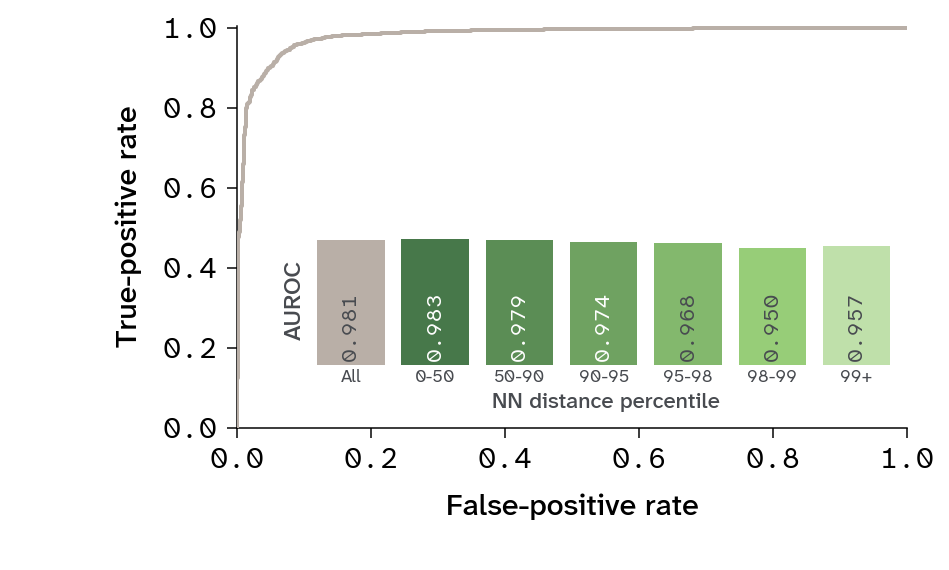

confusion matrix at logit > 0.5 on the 6,000-variant test split [rows = truth, cols = call]:
[[1698  117]
 [ 279 3906]]
  precision 0.9709  recall 0.9333  accuracy 0.9340  false positives 117 of 4,023 calls


In [19]:
# One panel: the pooled held-out ROC, with the campaign's two thresholds marked where they actually
# fall -- a tight cluster against the corner, which is the point, the shortlist bar carrying the
# larger marker because it is the one a design has to clear. The inset is the aggregate's own
# caveat: AUROC inside each stratum of the campaign's distance statistic, so the curve and the
# question "does it hold where the designs sit" are read in one place. Inset bars run from 0.5, the
# floor of the metric, and carry their value, since the whole range they move over is a few points.
from matplotlib.colors import to_rgb  # noqa: E402
from matplotlib.patches import Rectangle  # noqa: E402

r = ROC[DRAWN]

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.25, right=0.955, bottom=0.25, top=0.955)

ax.plot(r["fpr"], r["tpr"], color=r["color"], lw=2, zorder=4)
ax.set(xlim=(0, 1), ylim=(0, 1.005), xlabel="False-positive rate", ylabel="True-positive rate")
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)

# Inset: the drawn curve's own area at the left in the curve's own colour, set apart by a gap, then
# one bar per distance stratum, each carrying its value inside. It has axis titles rather than a
# heading, so it reads as a chart in its own right; an inset inherits this notebook's large rcParams
# text sizes, so every size is set explicitly.
inset = ax.inset_axes([0.10, 0.155, 0.9, 0.325], zorder=7)
inset.set_facecolor("white")
# The inset keeps a ramp of its own rather than Figures 4-6's blues: greens, because the subject is
# green fluorescence, running from the dark end at the innermost stratum to the pale end at
# percentile 99+, so the bars fade as the population walks away from the DMS cloud.
INSET_C = [apc.gradients.greens.to_mpl_cmap()(v)      # apc gradients run dark -> light
           for v in np.linspace(0.0, 0.78, len(STRAT_AUROC))]
xs = np.r_[-1, np.arange(len(STRAT_AUROC))]
colors = [r["color"]] + INSET_C
inset.bar(xs, [s["auroc"] for s in INSET_BARS], color=colors, width=0.8, edgecolor="none",
          zorder=3)
for x, s, c in zip(xs, INSET_BARS, colors):
    # The ramp crosses from dark to pale under the numerals, so each is set by the luminance of its
    # own bar: white while the green still carries it, Charcoal once it does not -- which is also
    # what the pale Chateau of the unstratified bar needs.
    lum = float(np.dot(to_rgb(c), (0.299, 0.587, 0.114)))
    inset.annotate(f"{s['auroc']:.3f}", xy=(x, 0.518), rotation=90, ha="center", va="bottom",
                   **{**NUMBER_NOTE, "fontsize": 11,
                      "color": "white" if lum < 0.62 else str(apc.charcoal)})
inset.set_ylim(0.5, 1.0)
inset.set_yticks([])
inset.set_xlim(-1.55, len(STRAT_AUROC) - 0.4)
inset.set_xticks(xs)
inset.set_xticklabels([s["label"] for s in INSET_BARS], fontsize=10)
inset.tick_params(length=0, labelsize=9, colors=str(apc.charcoal), pad=2)
inset.set_xlabel("NN distance percentile", fontsize=11,
                 labelpad=4, color=str(apc.charcoal))
inset.set_ylabel("AUROC", fontsize=12, labelpad=0, color=str(apc.charcoal))
for side in inset.spines.values():
    side.set_visible(False)

fig.savefig(f"{FIGDIR}/brightness_roc_operating_points.svg")
fig.savefig(f"{FIGDIR}/brightness_roc_operating_points.png", dpi=200)
plt.show()

# The operating point as counts, kept as a printout now that the inset carries the strata instead.
yhat = (te.logit > THR_SHORTLIST).astype(int).to_numpy()
ytrue = te.y.to_numpy()
CM = np.array([[int(((ytrue == i) & (yhat == j)).sum()) for j in (0, 1)] for i in (0, 1)])
print(f"confusion matrix at logit > 0.5 on the {len(te):,}-variant test split "
      f"[rows = truth, cols = call]:\n{CM}")
print(f"  precision {CM[1, 1] / CM[:, 1].sum():.4f}  recall {CM[1, 1] / CM[1].sum():.4f}  "
      f"accuracy {(CM[0, 0] + CM[1, 1]) / CM.sum():.4f}  "
      f"false positives {CM[0, 1]:,} of {CM[:, 1].sum():,} calls")


**Figure 3. The classifier's ranking of held-out variants is close to perfect, and it barely weakens
in the sparse corner of the distribution the designs occupy.** ROC on the 6,000 held-out test
variants (Chateau) with the chance diagonal. Inset: AUROC of the same classifier, unstratified at the
left in the curve's own colour — the area of the curve beside it — and then inside each stratum of
the campaign's distance statistic, on the 97,499 never-fitted variants of Section 3, binned by
percentile of the DMS cloud's own self-neighbour distances (the same bins as Figures 4-6), on
32,030 / 35,154 / 5,846 / 3,835 / 1,379 / 1,120 variants. The strata carry a greens ramp of their own
that pales as they move outward, rather than Figures 4-6's blues. Inset bars run from 0.5, the floor of the
metric, and carry their value, because the whole range they cover is three points.

**The campaign never uses most of this curve.** Its two thresholds are points on it, not regions: at
`logit > 0` the model runs at TPR 0.945 / FPR 0.077, and at the shortlist bar `logit > 0.5` at
TPR 0.933 / FPR 0.065 — two points a few hundredths apart, both jammed into the top-left corner, both
printed above rather than marked, since at this panel size two markers that close read as one. The
area summarizes the whole threshold range including the long right-hand stretch where everything is
called bright, which the campaign never enters; everything it does is decided in that corner.

What the corner is worth is a ratio, not an area. **Precision cannot be carried from DMS variants to
designs, and LR+ = TPR / FPR can.** Precision depends on the population's bright rate — 70% in the
test split, unknown and much lower in a pool of 10-substitution pocket designs — so the 97.1% this
model achieves at the shortlist bar is not a prediction about a shortlist. The likelihood ratio is a
property of the classifier at a fixed threshold, so it multiplies whatever the design pool's prior
odds happen to be, which is what Figure 4 and Section 7 do with it. Two are printed above: 14.5 over
all held-out variants, and **32.0** over the 914 carrying at least five substitutions — the
design-matched stratum, whose curve is not drawn because it lies on top of this one (areas 0.978
against 0.981) while the number that separates them is invisible as a shape. At higher edit load the
false-positive rate falls faster than the true-positive rate does (0.065 → 0.027 against 0.933 →
0.850), because a heavily mutated variant that is dim is easy to call. One caveat on reading that
2.2x as the classifier being *better* on design-like variants: part of it is the threshold drift
Figure 6 isolates — harder populations score lower overall, so a bar fixed at 0.5 sits further out in
their score distribution and trades recall for selectivity.

**The inset is the aggregate's own caveat, and it comes back mild.** An AUROC over all held-out
variants says nothing about whether the ordering survives away from the DMS cloud, which is exactly
where the designs sit. It largely does: 0.981 unstratified, 0.983 in the innermost half of the cloud,
0.974 and 0.968 in the percentile 90-95 and 95-98 bands the in-distribution gate admits designs into,
and 0.950-0.957 in the two outermost strata — a drift of three points across a distance range over
which precision falls from 0.985 to 0.82 (Figure 5). The leftmost bar is the test split and the other
six are the wide pool, which is not the easier population: unstratified it scores 0.984. So what
degrades out there is not the ranking but where a fixed bar sits on it — the median logit of a
*bright* variant falls from +6.04 to +1.53, so `logit > 0.5` slides into the tail. Figures 4-6 are
that in three readings: what the multiplier is worth against an unknown prior, the precision the
campaign actually gets at DMS prevalence, and the rates underneath both.

The same operating point in plain counts, printed below: of 6,000 held-out variants — 4,185 truly
bright, 1,815 truly dim — the bar calls 4,023 bright, and 3,906 of those are. So 117 dim variants get
through, and 279 bright ones are thrown away with the 1,698 correctly rejected. Recall being the
cheaper error is why the campaign can afford the stricter bar at all — it throws away thousands of
candidates by construction.

## 5. Metric 2 — precision inside the in-distribution gate's own stratum

The campaign's second filter is a distance test: a design is in-distribution when its nearest
neighbour in the 40k DMS cloud, in z-scored ESM-2 max-pool space, is no further than the cloud's own
99th-percentile self-neighbour distance (30.2). The intent is "no further from a real DMS variant
than the DMS variants are from each other".

That gate defines its own evaluation stratum. If designs are admitted at the 98th percentile of the
cloud's self-distance distribution, then the number that matters is precision **among held-out
variants in that same sparse corner** — not precision over a test set whose median variant sits at
the 50th percentile, 13 distance units closer in.

Two figures, in the order the numbers should be read. **Figure 4** takes each stratum's likelihood
ratio at the campaign's bar and turns it into precision as a function of the bright rate among
candidates — the form that transports, since a design pool's bright rate is not a DMS library's
and nobody has measured it. **Figure 5** is the same six strata read at the one bright rate this
data does supply, each stratum's own. They are one identity read in two directions —
precision = LR+ π / (LR+ π + 1 − π) — so every bar in Figure 5 is a single point on its own curve
in Figure 4, and the curve is what survives the move to a population with a different prior.

In [13]:
# The campaign's design pools and their distance to the DMS cloud, computed exactly as
# make_shortlist_case.py computes it: the same 40k max-pool reference, the same z-scoring, the same
# DMS-window framing seq[3:238], and the same 1-NN distance. Nothing is re-embedded -- design
# embeddings come from the campaign's own sequence-keyed cache, the guided arms log the deployed
# model's logit as `pred_bright` during the run, and only the two unguided arms (which have no
# brightness term, hence no logged logit) are scored here, with the checkpoint the campaign loads.
import hashlib  # noqa: E402
from pathlib import Path  # noqa: E402

CAMPP = Path(CAMP)
EGFP = json.load(open(CAMPP / "design_windows_egfp_tierB.json"))["windows"]["EGFP"]["scaffold_seq"]
REGIME_NPZ = f"{DMS}/campaign_regime_cache.npz"     # git-ignored analysis cache
UNGUIDED = ("ESM-gibbs", "MSA-gibbs")


def design_pool(paths):
    """Every design a strategy produced, deduplicated on sequence, as make_shortlist_case.py does."""
    d = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    d = d[d["round"] >= 1].drop_duplicates("designed_seq").reset_index(drop=True)
    d["n_mut"] = [sum(a != b for a, b in zip(s, EGFP)) for s in d.designed_seq]
    return d


ARMS = {
    "DMS-guide": design_pool([CAMPP / "brightness-guided/guided_design/designs_lam-bright60_lam-edit10"
                              / f"design_EGFP-{t}.csv" for t in ("EBFP", "mOrange")]
                             + sorted(CAMPP.glob("lambda_sweep/designs/*/design_EGFP-*.csv"))),
    "MSA-guide": design_pool(sorted(CAMPP.glob("msa-guided/designs/*/design_EGFP-*.csv"))),
    "ESM-gibbs": design_pool([CAMPP / "gibbs-sampling/designs/design_EGFP.csv"]),
    "MSA-gibbs": design_pool([CAMPP / "msa-gibbs/designs/design_EGFP.csv"]),
}


def unguided_logits(path=REGIME_NPZ):
    """Deployed-classifier logits for the two arms that log none of their own, cached."""
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        if all(f"arm_{a}" in z.files for a in UNGUIDED):
            return {a: z[f"arm_{a}"] for a in UNGUIDED}
    base, meta = pm.load_model("../fpdesign/models/brightness_cnn-max-d2_40k.pt", dev, out=1)
    net = pm.wrap(base, meta.get("mean", 0.0) or 0.0, meta.get("std", 1.0) or 1.0, dev)

    @torch.no_grad()
    def logit_of(seqs, bs=32):
        out = []
        for i in range(0, len(seqs), bs):
            H, m = pm.resid_embed(list(seqs[i:i + bs]), dev)
            out.append(net(H, m).float().cpu().numpy().ravel())
        return np.concatenate(out)

    cache = {f"arm_{a}": logit_of(ARMS[a].designed_seq.tolist()) for a in UNGUIDED}
    np.savez(path, **cache)
    return {a: cache[f"arm_{a}"] for a in UNGUIDED}


for arm, lg in unguided_logits().items():
    ARMS[arm]["pred_bright"] = lg

cache = np.load(CAMPP / ".embed_cache" / "maxpool_esm2_650M.npz")
CACHE_IDX = {k: i for i, k in enumerate(cache["keys"].astype(str))}
CACHE_EMB = cache["emb"]


def design_nn_distance(seqs, chunk=1024):
    """1-NN L2 distance to the z-scored 40k DMS cloud, from the campaign's embedding cache."""
    keys = [hashlib.sha1(s[3:238].encode()).hexdigest() for s in seqs]
    missing = [k for k in keys if k not in CACHE_IDX]
    assert not missing, (f"{len(missing)} design sequences are not in the campaign's embed cache -- "
                         "rerun make_shortlist_case.py / visualize_campaign.ipynb to populate it")
    E = torch.as_tensor((CACHE_EMB[[CACHE_IDX[k] for k in keys]] - mu) / sd,
                        dtype=torch.float32, device=dev)
    out = []
    with torch.no_grad():
        for i in range(0, len(E), chunk):
            out.append(torch.cdist(E[i:i + chunk], Zref).min(dim=1).values.cpu().numpy())
    return np.concatenate(out)


for arm, d in ARMS.items():
    d["nn_dist"] = design_nn_distance(d.designed_seq.tolist())
    d["is_id"] = d.nn_dist <= ID_CUT

# The percentile of the cloud's own self-neighbour distances that a design distance corresponds to.
SELF_NN = np.sort(held.nn_dist.to_numpy())          # all 40,000 rows, self-excluded 1-NN
pct_of = lambda v: float(np.searchsorted(SELF_NN, v) / len(SELF_NN) * 100)

# PCTS/EDGES/STRAT_LABELS are the strata defined in Section 3, so Figures 4-6 and the Figure 3
# inset all bin the same way; the variants binned into them here are the wide held-out pool.
def distance_strata(frame):
    out = []
    for i in range(len(PCTS) - 1):
        g = frame[(frame.nn_dist >= EDGES[i]) & (frame.nn_dist < EDGES[i + 1])]
        s = gate(g)
        s.update(label=STRAT_LABELS[i], lo=EDGES[i], hi=EDGES[i + 1],
                 ci=wilson(round(s["precision"] * s["n_kept"]), s["n_kept"]))
        out.append(s)
    return out


strata = distance_strata(pool)
strata_test = distance_strata(te)          # what the same figure showed on the test split alone

print(f"in-distribution cut (cloud's own 99th pct self-NN distance) = {ID_CUT:.2f}")
print(f"{'pct':>8} {'distance':>13} {'n':>7} {'bright':>7} {'kept':>6} {'precision':>10} "
      f"{'95% CI':>14}   {'(test split: kept, precision)':>30}")
for s, t in zip(strata, strata_test):
    hi = "inf" if not np.isfinite(s["hi"]) else f"{s['hi']:.1f}"
    span = f"{s['lo']:.1f}-{hi}"
    band = "[{:.2f}, {:.2f}]".format(*s["ci"])
    was = f"{t['n_kept']:>6,d}  {t['precision']:.3f}"
    print(f"{s['label']:>8} {span:>13} {s['n']:7,d} {s['prevalence']:7.3f} "
          f"{s['n_kept']:6,d} {s['precision']:10.4f} {band:>14}   {was:>30}")
print()
for arm, d in ARMS.items():
    sel = d[d.is_id & (d.pred_bright > THR_SHORTLIST)]
    print(f"{arm:10} n={len(d):5d} edit load median {np.median(d.n_mut):4.0f} | "
          f"pool median distance {d.nn_dist.median():5.1f} (cloud pct "
          f"{pct_of(d.nn_dist.median()):5.1f}) | in-distribution {d.is_id.mean():.3f} | "
          f"ID & bright {len(sel):5d} ({len(sel) / len(d):.3f})"
          + (f" | their median distance {sel.nn_dist.median():.1f} "
             f"(pct {pct_of(sel.nn_dist.median()):.1f})" if len(sel) else ""))

in-distribution cut (cloud's own 99th pct self-NN distance) = 30.21
     pct      distance       n  bright   kept  precision         95% CI    (test split: kept, precision)
    0-50      2.7-13.1  32,030   0.865 27,097     0.9855   [0.98, 0.99]                     2,136  0.974
   50-90     13.1-21.4  35,154   0.647 22,070     0.9610   [0.96, 0.96]                     1,688  0.971
   90-95     21.4-24.3   5,846   0.294  1,599     0.9062   [0.89, 0.92]                       123  0.935
   95-98     24.3-27.7   3,835   0.167    572     0.8392   [0.81, 0.87]                        55  0.964
   98-99     27.7-30.2   1,379   0.102    123     0.8211   [0.74, 0.88]                        11  0.909
     99+      30.2-inf   1,120   0.093     75     0.8400   [0.74, 0.91]                        10  0.900

DMS-guide  n= 2058 edit load median   10 | pool median distance  28.9 (cloud pct  98.6) | in-distribution 0.636 | ID & bright   525 (0.255) | their median distance 27.2 (pct 97.7)
MSA-guide  n= 54

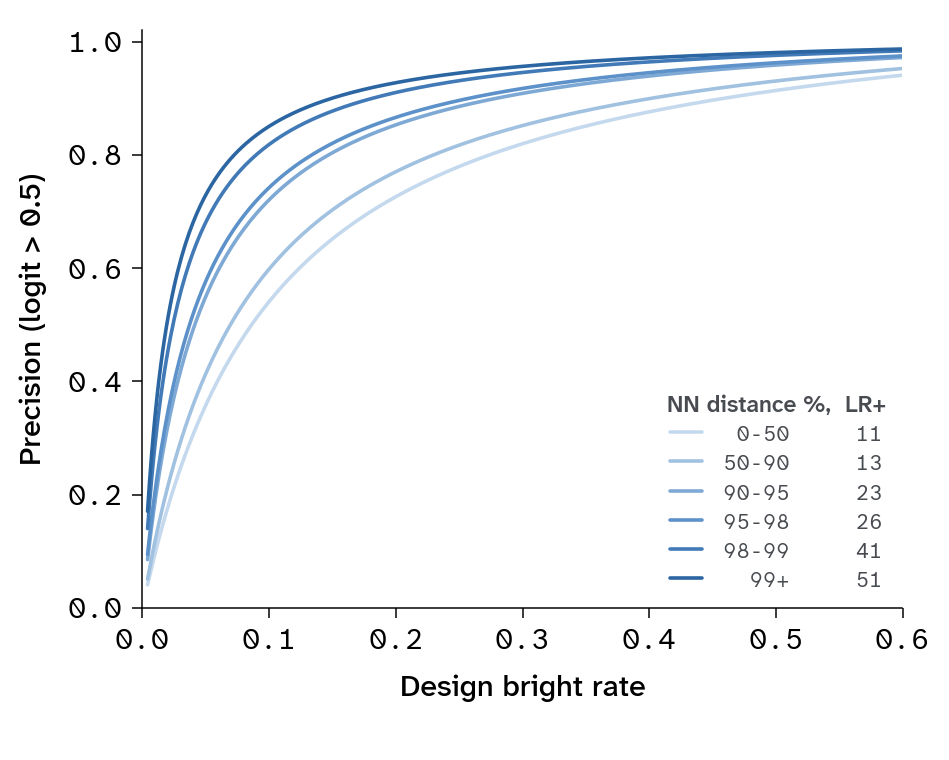

LR+ at the shortlist bar (logit > 0.5) per distance stratum, and the precision it
implies at a range of assumed bright rates among candidates:
     pct     LR+    kept  DMS rate  obs prec       2%      5%     10%     20%     30%
    0-50    10.6  27,097     0.865     0.985    0.178   0.358   0.541   0.726   0.820
   50-90    13.4  22,070     0.647     0.961    0.215   0.414   0.599   0.770   0.852
   90-95    23.2   1,599     0.294     0.906    0.322   0.550   0.721   0.853   0.909
   95-98    25.9     572     0.167     0.839    0.346   0.577   0.742   0.866   0.917
   98-99    40.6     123     0.102     0.821    0.453   0.681   0.819   0.910   0.946
     99+    51.3      75     0.093     0.840    0.511   0.730   0.851   0.928   0.956


In [14]:
# LR+ at the campaign's bar, per distance stratum, turned into the only precision statement that
# survives a change of population. `distance_strata` already reports the ratio; what this adds is the
# curve it implies over a bright rate that the design pool has and this dataset cannot measure. The
# marker on each curve is that stratum's own DMS bright rate, where the curve necessarily passes
# through the precision Figure 5 measures -- the assert is that identity, not a fit.
def ppv(lr, pi):
    """Precision of a positive call, from a likelihood ratio and a prior."""
    return lr * pi / (lr * pi + (1 - pi))


for s in strata:
    assert abs(ppv(s["lr_plus"], s["prevalence"]) - s["precision"]) < 5e-3, s["label"]

PRIOR = np.linspace(0.004, 0.6, 400)
DESIGN_STRATA = ("90-95", "95-98")        # the two bands the in-distribution gate admits designs into

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 0.8 * HALF_PANEL * PX))
fig.subplots_adjust(left=0.15, right=0.95, bottom=0.20, top=0.96)

for s, c in zip(strata, STRAT_C):
    ax.plot(PRIOR, ppv(s["lr_plus"], PRIOR), color=c, lw=1.8, zorder=3,
            label="{:>6}   {:>4.0f}".format(s["label"], s["lr_plus"]))

ax.set(xlim=(0, 0.6), ylim=(0, 1.02), xlabel="Design bright rate",
       ylabel="Precision (logit > 0.5)")
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)
leg = ax.legend(loc="lower right", frameon=False, handlelength=1.5, borderaxespad=0.8,
                labelspacing=0.35, prop={"family": "Atkinson Hyperlegible Mono", "size": 10.5},
                title="NN distance %,  LR+")
leg.get_title().set(fontsize=11.5, fontweight="semibold", color=str(apc.charcoal))
for t in leg.get_texts():
    t.set_color(str(apc.charcoal))
#ax.set_xscale("log")
fig.savefig(f"{FIGDIR}/brightness_stratum_lr_prior.svg")
fig.savefig(f"{FIGDIR}/brightness_stratum_lr_prior.png", dpi=200)
plt.show()

print(f"LR+ at the shortlist bar (logit > {THR_SHORTLIST}) per distance stratum, and the precision it")
print("implies at a range of assumed bright rates among candidates:")
SHOW = [0.02, 0.05, 0.10, 0.20, 0.30]
print(f"{'pct':>8} {'LR+':>7} {'kept':>7} {'DMS rate':>9} {'obs prec':>9}   "
      + "  ".join(f"{p:>6.0%}" for p in SHOW))
for s in strata:
    print(f"{s['label']:>8} {s['lr_plus']:7.1f} {s['n_kept']:7,d} {s['prevalence']:9.3f} "
          f"{s['precision']:9.3f}   " + "  ".join(f"{ppv(s['lr_plus'], p):6.3f}" for p in SHOW))


**Figure 4. Each distance stratum's likelihood ratio, read against the bright rate nobody has
measured — and the strata where the campaign's precision looks worst are the ones whose multiplier is
strongest.** Precision of the bright call at the campaign's shortlist bar (`logit > 0.5`) as a
function of the assumed bright rate among candidates, one curve per stratum of the DMS cloud's own
neighbour-distance percentiles, each drawn from that stratum's measured positive likelihood ratio via
precision = LR+ π / (LR+ π + 1 − π). LR+ at the bar runs **10.6 / 13.4 / 23.2 / 25.9 / 40.6 / 51.3**
across percentiles 0-50 / 50-90 / 90-95 / 95-98 / 98-99 / 99+, measured over the 97,499 never-fitted
variants of Section 3 (the key carries them, rounded). Markers sit at each stratum's own DMS bright
rate, where the curve necessarily passes through the precision Figure 5 measures; the innermost two
strata's bright rates, 0.865 and 0.647, are off this axis to the right.

**The ordering is the reverse of Figure 5's, and that is the point.** At DMS prevalence the outer
strata look worst — precision 0.839 and 0.821 against 0.985 innermost — but that gap is prevalence,
not discrimination: the same populations carry the *largest* multipliers, because a bar fixed at 0.5
sits further out in a score distribution that shrinks with distance. Read at a common prior the
ranking inverts. At a 5% bright rate among candidates, the two bands the in-distribution gate admits
designs into (percentile 90-95 and 95-98, LR+ 23.2 and 25.9) give precision **0.550 and 0.577**,
while the innermost stratum's LR+ 10.6 would give only 0.358; at 10% they give 0.721 and 0.742
against 0.541. The 98-99 and 99+ strata climb higher still (0.681 and 0.730 at a 5% prior) but rest
on 123 and 75 kept variants, so their curves are the least certain on the panel. Read along
its own curve, the 98-99 stratum's LR+ of 40.6 gives precision **0.453 / 0.681 / 0.819 / 0.910** at
assumed design bright rates of 2 / 5 / 10 / 20% — the steepest climb on the panel, and the one
resting on the fewest variants.

**What this figure cannot do is pick the prior.** The whole family spans a factor of two in precision
over any plausible design bright rate, and nothing in a DMS library measures that rate for a pool of
10-substitution pocket designs — Section 7 turns the same arithmetic into expected wet-lab yield and
says what would settle it. The other caveat is Figure 6's: these ratios are read at a fixed bar whose
recall collapses from 0.964 to 0.606 across the same strata, so the rise along this family is partly
the campaign trading recall for selectivity, which for a strategy that generates thousands of
candidates for ten wells is a good trade — but it is a trade, not a free gain in discrimination.

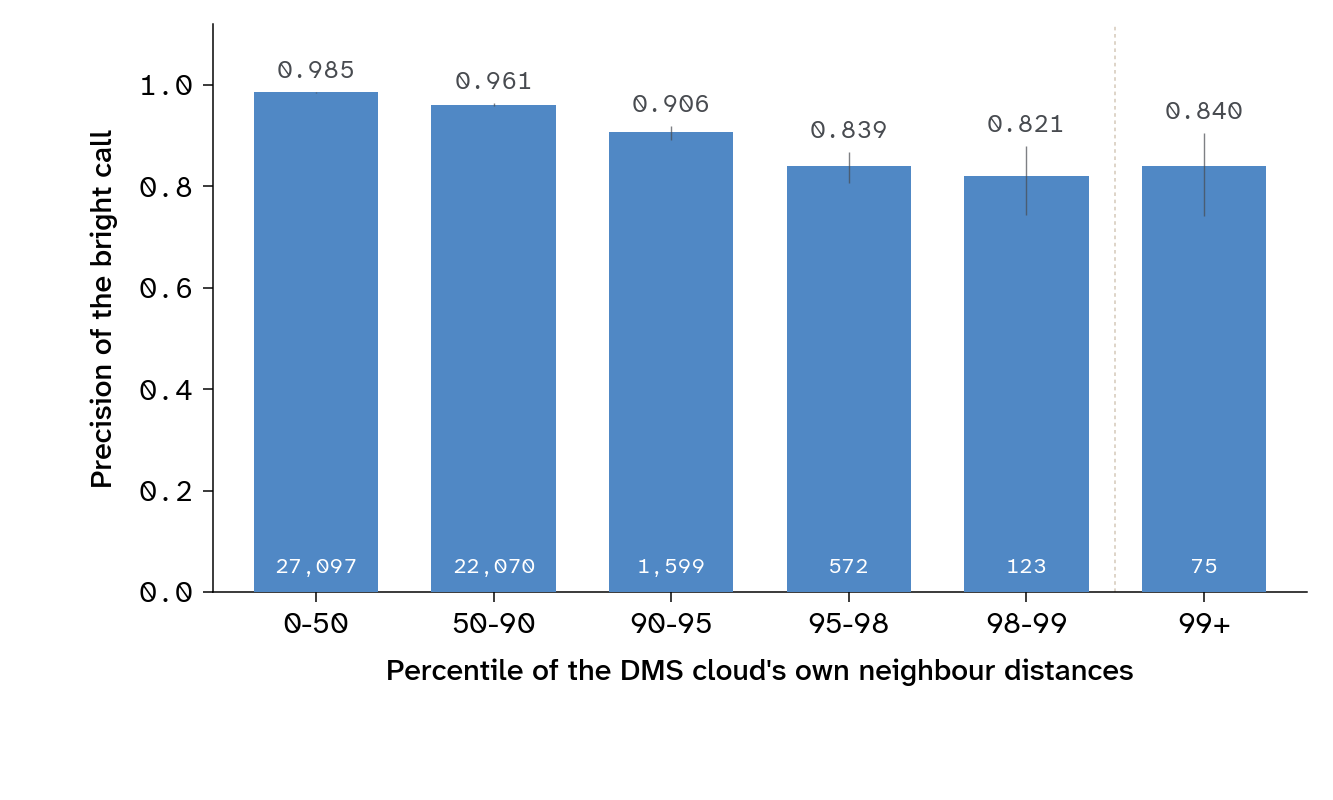

held-out variants beyond the 95th percentile: 6,334 of 97,499 (6.5%) -- on the test split alone it was 287 of 6,000


In [15]:
# Precision per stratum of the campaign's own distance statistic. Where the designs sit on that axis
# is a printout above rather than a second panel; the numbers are quoted in the caption.
fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 400 * PX))
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.26, top=0.97)

xs = np.arange(len(strata))
vals = np.array([s["precision"] for s in strata])
cis = np.array([s["ci"] for s in strata])
ax.bar(xs, vals, color=HIGHLIGHT, width=0.7, edgecolor="none", zorder=3)
ax.errorbar(xs, vals, yerr=[vals - cis[:, 0], cis[:, 1] - vals], fmt="none",
            ecolor=str(apc.charcoal), elinewidth=0.7, capsize=1.5, alpha=0.7, zorder=4)
for x, s, v, ci in zip(xs, strata, vals, cis):
    ax.annotate(f"{v:.3f}", xy=(x, ci[1]), xytext=(0, 5), textcoords="offset points", ha="center",
                va="bottom", **{**NUMBER_NOTE, "fontsize": 12.5})
    ax.annotate(f"{s['n_kept']:,}", xy=(x, 0.03), ha="center", va="bottom",
                **{**NUMBER_NOTE, "fontsize": 11, "color": "white"})
# The in-distribution cut is the 99th percentile, so it falls between the last two bars: everything
# left of the rule is admitted by the gate, the bar right of it is the region the gate rejects.
ax.axvline(len(strata) - 1.5, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.9, zorder=2)
ax.set(xticks=xs, xticklabels=[s["label"] for s in strata], ylim=(0, 1.12),
       yticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
       xlabel="Percentile of the DMS cloud's own neighbour distances",
       ylabel="Precision of the bright call")
apc.mpl.style_plot(ax, monospaced_axes="y")
bare(ax)

fig.savefig(f"{FIGDIR}/brightness_id_distance.svg")
fig.savefig(f"{FIGDIR}/brightness_id_distance.png", dpi=200)
plt.show()

print(f"held-out variants beyond the 95th percentile: {int((pool.nn_dist >= EDGES[3]).sum()):,} of "
      f"{len(pool):,} ({(pool.nn_dist >= EDGES[3]).mean():.1%}) -- on the test split alone it was "
      f"{int((te.nn_dist >= EDGES[3]).sum())} of {len(te):,}")

**Figure 5. Precision falls steadily the further a variant sits from the DMS cloud — chiefly because
those variants are mostly dead, not because the model fails on them — and the in-distribution gate
admits designs into the band where it has already dropped to about 82%.**
Precision of the bright call at the shortlist bar (`logit > 0.5`) per stratum of the campaign's own
distance statistic — the 1-NN distance to the 40,000-variant reference cloud in z-scored ESM-2
max-pool space, binned by percentile of the cloud's self-neighbour distances — measured over the
**97,499 held-out variants** of Section 3. Wilson 95% intervals; the precision is printed above
each bar and the number of variants the gate kept inside it. The dashed rule is the in-distribution
cut, which is the cloud's 99th percentile: the gate admits everything to its left and rejects the
open-ended stratum to its right.

The decline is monotone and, at this sample size, resolvable: **0.985** (percentile 0-50, 27,097 kept
variants), **0.961** (50-90, 22,070), **0.906** (90-95, 1,599), **0.839** (95-98, 572), **0.821**
(98-99, 123) and 0.840 beyond the gate (75). Intervals are ±0.01 or less out to the 90th percentile
and ±0.06-0.09 in the outer two strata, so the first four are separated from each other while the last
two are not. Most of the fall is prevalence: the bright rate among held-out variants drops from 86.5%
in the innermost stratum to 9-10% in the outer two, because sitting far from the cloud in this space
goes with carrying more substitutions. Figure 6 separates the two explanations and shows that unchanged
rates would have produced a *steeper* fall than this one, so nothing here should be read as the
classifier breaking down.

Widening the evaluation set is what makes that statement possible, and it corrected the earlier one.
On the 6,000-row test split the same strata read 0.974 / 0.971 / 0.935 / **0.964** / 0.909 / 0.900 on
2,136 / 1,688 / 123 / **55** / 11 / 10 kept variants — flattering precisely where it was thinnest,
since the 95-98 band's 0.964 on 55 variants is really 0.839 on 572, and no ordering could be read out
of intervals ±0.20 wide. The wider pool is not an easier population: its overall AUROC is 0.984
against the test split's 0.981, and precision at the shortlist bar is 0.971 either way.

Where the designs fall on this axis is the reason the right-hand strata matter, and the cell above
prints it: the DMS-guided pool's median design sits at distance 28.9, the 98.6th percentile of the
cloud's own distances, and the designs clearing both gates sit at 27.2 (97.7th percentile) for
DMS-guided and 21.4 (90.0th) for MSA-guided, 23.3 (93.6th) pooled. Only 64% of the DMS-guided pool and
70% of the MSA-guided pool is in-distribution at all — and neither unguided arm is: ESM-gibbs designs
sit at 42.7 (0 of 288 inside the gate) and MSA-gibbs at 35.2 (8%), so the ID test alone separates
guided from unguided generation. The practical reading is now quantitative rather than a shrug: the
gate admits designs into a band where the classifier's precision is 0.82-0.91 rather than the 0.97 its
aggregate suggests, and moving the bar in to the 95th percentile would buy about seven points of
precision (0.906 against 0.839) at the cost of pool depth.

## 6. Metric 3 — is the classifier degrading out of distribution, or is the population getting harder?

Figure 5 answers a question the campaign asks and hides a different one inside it. Precision within a
distance stratum can fall for two unrelated reasons: the classifier's own hit and false-alarm rates
can degrade as variants move away from the training cloud, or the stratum's bright rate can fall so
that unchanged rates yield less precision. The two have opposite implications — the first says the
model is out of its depth where the designs live, the second says the model is fine and the biology
is harder — and no precision number can separate them, because precision mixes both.

What separates them is the pair of rates *conditional on the truth*, which is exactly what a ROC
curve per stratum shows. Three readings come out of it, and they disagree in an instructive way:

| Reading | What it isolates |
|---|---|
| Precision recomputed with the innermost stratum's rates and each stratum's own prevalence | How much of Figure 5 is prevalence alone |
| LR+ = TPR / FPR **swept over thresholds**, per stratum | The multiplier the campaign buys, and how much more a stricter bar would buy |
| LR+ read off each stratum's ROC at a **matched recall** | The classifier compared with itself, with the threshold's drift taken out |

The second is what the campaign spends wells on, and it is the one plotted: a design campaign that
can generate thousands of candidates for ten wells is not paying for recall, so the only question
about a threshold is what multiplier it returns. The third is reported in the printout rather than
plotted, because it answers a different question — "is the model degrading" — and the two answers
point in opposite directions for a reason the figure has to be read carefully to see.

In [16]:
# The two rates behind Figure 5's precision. `distance_strata` already reports TPR, FPR and LR+ at
# the campaign's bar; what is added here is (1) the prevalence counterfactual, which asks how much of
# Figure 5 needs no change in the classifier at all, and (2) the same multiplier read at a matched
# recall, which is the only way to compare strata without the fixed bar moving underneath them.
RECALL_MATCH = 0.90          # a recall every stratum still reaches, though at very different logits
N_BOOT = 300


def katz(tpr, n_tp, fpr, n_fp, z=1.96):
    """95% CI for a ratio of two proportions, on the log scale.

    LR+ is a ratio, so its interval is asymmetric, and the outer strata rest on ~1,000 dim variants
    where that asymmetry is large. Wilson (used for the precisions) is the wrong tool here.
    """
    if n_tp == 0 or n_fp == 0:
        return (np.nan, np.nan)
    se = np.sqrt((1 - tpr) / n_tp + (1 - fpr) / n_fp)
    return (tpr / fpr * np.exp(-z * se), tpr / fpr * np.exp(z * se))


def lr_at_recall(frame, target=RECALL_MATCH):
    """(multiplier, logit) this stratum would show if its threshold were moved to hit `target`."""
    fpr, tpr, thr = roc_curve(frame.y, frame.logit)
    f = float(np.interp(target, tpr, fpr))
    return (target / f if f > 0 else np.inf), float(np.interp(target, tpr, thr))


def lr_at_recall_ci(frame, target=RECALL_MATCH, n=N_BOOT):
    """Percentile CI for the above. The matched-recall threshold is re-chosen inside every resample,
    so the interval includes the cost of not knowing where that threshold is."""
    rng = np.random.default_rng(RNG_SEED)
    y, s = frame.y.to_numpy(), frame.logit.to_numpy()
    out = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if 0 < y[i].sum() < len(i):
            f_, t_, _ = roc_curve(y[i], s[i])
            f = float(np.interp(target, t_, f_))
            if f > 0:
                out.append(target / f)
    if not out:
        return (np.nan, np.nan)
    return (float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5)))


SBINS = [pool[(pool.nn_dist >= EDGES[i]) & (pool.nn_dist < EDGES[i + 1])]
         for i in range(len(PCTS) - 1)]
INNER = strata[0]            # the reference rates for the counterfactual: percentile 0-50

SDIAG = []
for s, g in zip(strata, SBINS):
    keep, bright = g.logit > THR_SHORTLIST, g.y == 1
    lr_m, thr_m = lr_at_recall(g)
    pi = float(s["prevalence"])
    SDIAG.append(dict(
        label=s["label"], n=s["n"], n_dim=int((~bright).sum()), prev=pi, auroc=s["auroc"],
        tpr=s["recall"], fpr=s["fpr"], prec=s["precision"],
        fpr_arr=None, lr_fixed=s["lr_plus"],
        lr_fixed_ci=katz(s["recall"], int((keep & bright).sum()),
                         s["fpr"], int((keep & ~bright).sum())),
        lr_match=lr_m, lr_match_ci=lr_at_recall_ci(g), thr_match=thr_m,
        # what precision would have been if only the prevalence had changed
        prec_if_inner=INNER["recall"] * pi / (INNER["recall"] * pi + INNER["fpr"] * (1 - pi))))

ROC_BY_STRATUM = [roc_curve(g.y, g.logit) for g in SBINS]

print(f"{'pct':>7} {'n':>7} {'n_dim':>7} {'bright':>7} {'AUROC':>7} {'TPR':>6} {'FPR':>7} "
      f"{'LR+ @ bar':>10} {'95% CI':>15} {'LR+ @ rec .90':>14} {'95% CI':>14} {'logit':>7}")
for d in SDIAG:
    fixed_ci = "[{:.1f}, {:.1f}]".format(*d["lr_fixed_ci"])
    match_ci = "[{:.1f}, {:.1f}]".format(*d["lr_match_ci"])
    print(f"{d['label']:>7} {d['n']:7,d} {d['n_dim']:7,d} {d['prev']:7.3f} {d['auroc']:7.4f} "
          f"{d['tpr']:6.3f} {d['fpr']:7.4f} {d['lr_fixed']:10.1f} {fixed_ci:>15} "
          f"{d['lr_match']:14.1f} {match_ci:>14} {d['thr_match']:+7.2f}")

print("\nhow much of Figure 5 is prevalence?  (rates frozen at the percentile 0-50 stratum's)")
print(f"{'pct':>7} {'bright':>7} {'observed prec':>14} {'prec if rates never changed':>29} {'gap':>8}")
for d in SDIAG:
    print(f"{d['label']:>7} {d['prev']:7.3f} {d['prec']:14.4f} {d['prec_if_inner']:29.4f} "
          f"{d['prec'] - d['prec_if_inner']:+8.4f}")

print(f"\nthe fixed bar's drift: median logit of a BRIGHT variant, per stratum "
      f"(the bar itself never moves off {THR_SHORTLIST})")
for d, g in zip(SDIAG, SBINS):
    print(f"{d['label']:>7} bright {g[g.y == 1].logit.median():+6.2f}   "
          f"dim {g[g.y == 0].logit.median():+6.2f}   recall at the bar {d['tpr']:.3f}")

# Raising the bar is nearly free for a design campaign -- candidates are cheap, wells are not -- so
# the multiplier is swept over thresholds, not just read at the deployed one. The trap is in the
# denominator: LR+ = TPR / FPR, and out at the edge of the cloud a strict bar leaves single-digit
# false positives, at which point the ratio is a floor rather than an estimate.
THR_SWEEP = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]
FP_FLOOR = 10                 # below this many false positives, the point is drawn hollow

SWEEP = []
for g, d in zip(SBINS, SDIAG):
    y = (g.y == 1).to_numpy()
    row = []
    for t in THR_SWEEP:
        keep = (g.logit > t).to_numpy()
        tp, fp = int((keep & y).sum()), int((keep & ~y).sum())
        tpr, fpr = tp / max(int(y.sum()), 1), fp / max(int((~y).sum()), 1)
        row.append(dict(thr=t, tp=tp, fp=fp, n_kept=tp + fp, recall=tpr, fpr=fpr,
                        lr=(tpr / fpr if fp else np.inf),
                        lr_ci=katz(tpr, tp, fpr, fp) if fp else (np.nan, np.nan),
                        prec=tp / max(tp + fp, 1)))
    SWEEP.append(dict(label=d["label"], rows=row))

for field, fmt, title in (("lr", "{:10.1f}", "LR+ = TPR / FPR"),
                          ("recall", "{:10.3f}", "recall (the fraction of bright variants kept)"),
                          ("n_kept", "{:10,d}", "variants the bar admits"),
                          ("fp", "{:10,d}", "false positives the ratio rests on")):
    print(f"\n{title}")
    print(f"{'pct':>7} " + "".join("{:>10}".format("> " + str(t)) for t in THR_SWEEP))
    for s_ in SWEEP:
        print(f"{s_['label']:>7} " + "".join(fmt.format(r[field]) for r in s_["rows"]))

print("\nsame strata restricted to >= 5 substitutions, the design-relevant edit load:")
print(f"{'pct':>7} {'n':>7} {'n_dim':>7} {'AUROC':>7} {'LR+ @ bar':>10} {'LR+ @ rec .90':>14}")
for lab, g0 in zip([d["label"] for d in SDIAG], SBINS):
    g = g0[g0.n_mut >= 5]
    if len(g) < 50 or not 0 < g.y.sum() < len(g):
        print(f"{lab:>7} {len(g):7,d}       -- too few to report")
        continue
    m = gate(g, THR_SHORTLIST)
    print(f"{lab:>7} {len(g):7,d} {int((g.y == 0).sum()):7,d} {m['auroc']:7.4f} "
          f"{m['lr_plus']:10.1f} {lr_at_recall(g)[0]:14.1f}")

    pct       n   n_dim  bright   AUROC    TPR     FPR  LR+ @ bar          95% CI  LR+ @ rec .90         95% CI   logit
   0-50  32,030   4,328   0.865  0.9834  0.964  0.0908       10.6     [9.7, 11.7]           21.8   [18.9, 25.3]   +2.45
  50-90  35,154  12,400   0.647  0.9787  0.932  0.0694       13.4    [12.6, 14.3]           18.0   [16.6, 19.5]   +1.31
  90-95   5,846   4,130   0.294  0.9736  0.844  0.0363       23.2    [19.8, 27.2]           15.1   [12.8, 18.3]   -0.57
  95-98   3,835   3,193   0.167  0.9680  0.748  0.0288       25.9    [21.1, 31.9]           12.4   [10.1, 16.8]   -1.81
  98-99   1,379   1,239   0.102  0.9505  0.721  0.0178       40.6    [26.5, 62.3]            9.1    [3.0, 20.6]   -3.26
    99+   1,120   1,016   0.093  0.9571  0.606  0.0118       51.3    [28.6, 91.9]           10.3    [2.6, 18.9]   -3.59

how much of Figure 5 is prevalence?  (rates frozen at the percentile 0-50 stratum's)
    pct  bright  observed prec   prec if rates never changed      gap
   0

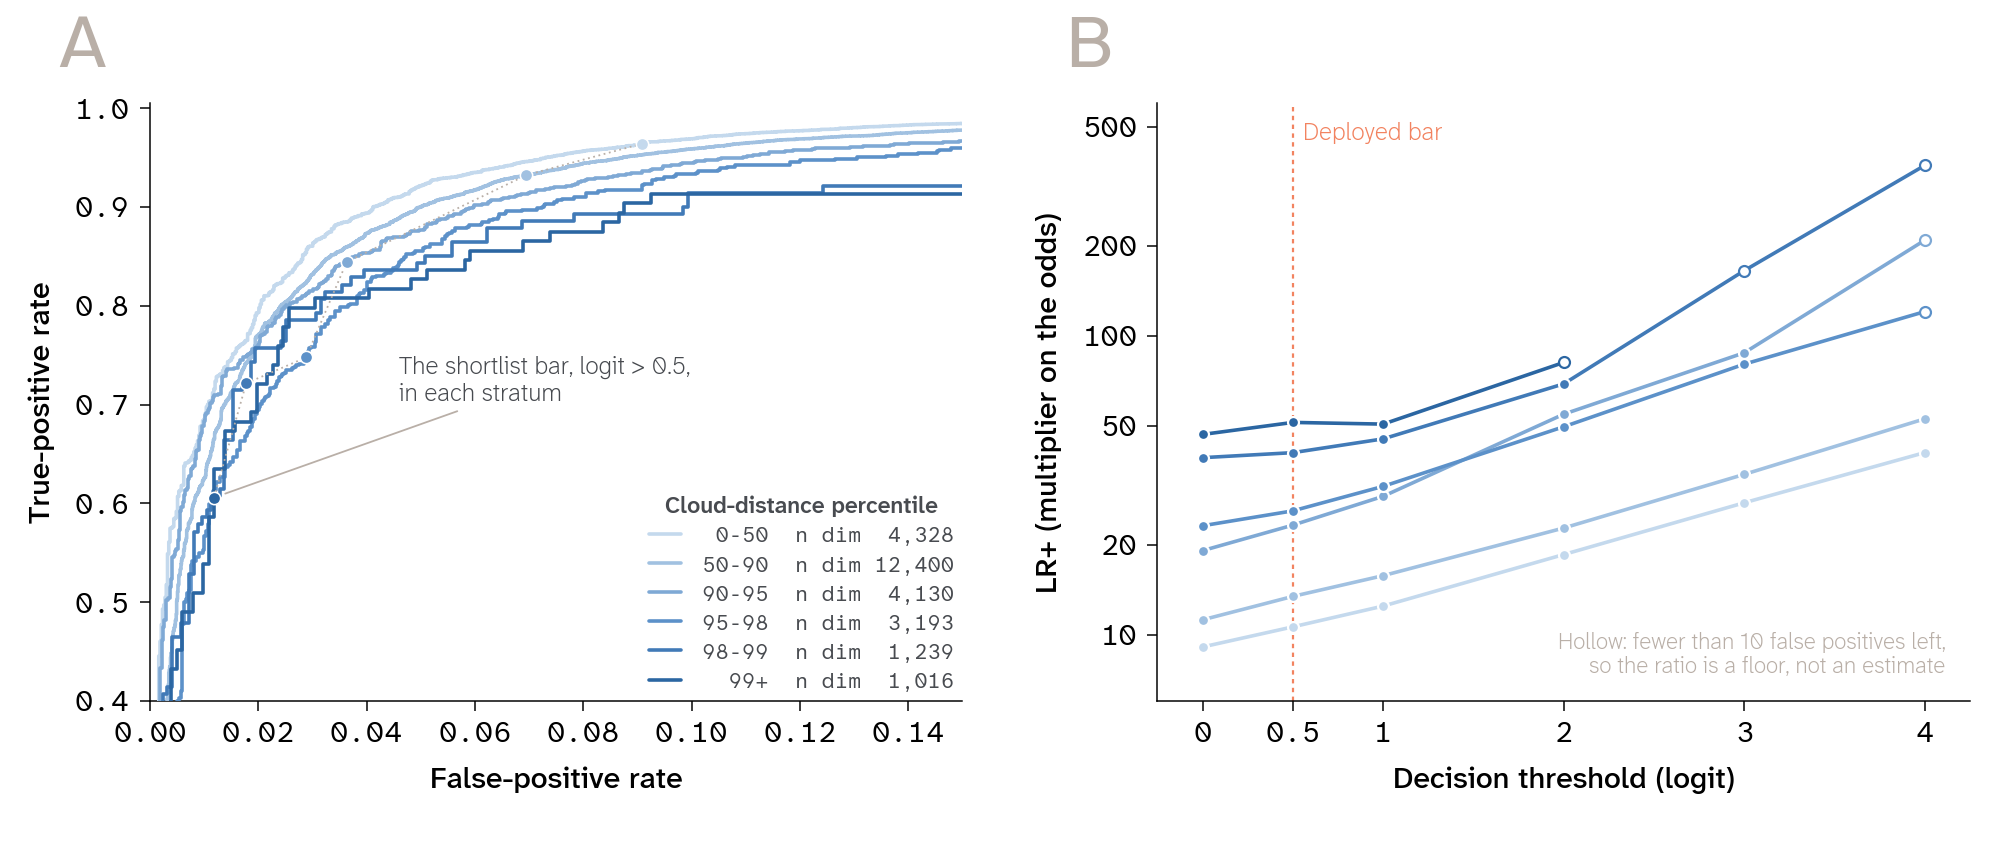

across the strata: prevalence 0.865 -> 0.093, AUROC 0.9834 -> 0.9571, LR+ at the bar 10.6 -> 51.3 (recall 0.964 -> 0.606), LR+ at matched recall 21.8 -> 10.3
largest prevalence-only gap: stratum 99+ would sit at 0.521 on unchanged rates and is observed at 0.840

what raising the bar buys where the designs sit, and what it costs:
  pct  90-95  logit > 0.5 -> > 2:  LR+  23.2 ->   54.7   recall 0.844 -> 0.728   admits 1,599 -> 1,304   on 55 false positives
  pct  90-95  logit > 0.5 -> > 4:  LR+  23.2 ->  208.9   recall 0.844 -> 0.455   admits 1,599 -> 790   on 9 false positives
  pct  95-98  logit > 0.5 -> > 2:  LR+  25.9 ->   49.6   recall 0.748 -> 0.621   admits 572 -> 439   on 40 false positives
  pct  95-98  logit > 0.5 -> > 4:  LR+  25.9 ->  120.5   recall 0.748 -> 0.340   admits 572 -> 227   on 9 false positives


In [17]:
# Panel A: one ROC per distance stratum, zoomed to the corner the campaign operates in, with the
# shortlist bar marked on each curve -- the markers walk down and left, which is the fixed bar sliding
# into the tail as the scores shrink. Panel B: the two multipliers that walk in opposite directions.
assert len(STRAT_C) == len(SDIAG)     # the stratum colours are Section 3's, shared with Figure 3
FPR_MAX = 0.15

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, 430 * PX))
fig.subplots_adjust(left=0.075, right=0.985, bottom=0.185, top=0.88, wspace=0.24)

ax = axes[0]
for (fpr, tpr, _), d, c in zip(ROC_BY_STRATUM, SDIAG, STRAT_C):
    ax.plot(fpr, tpr, color=c, lw=1.8, zorder=3,
            label="{:>6}  n dim {:>6,}".format(d["label"], d["n_dim"]))
walk = [(d["fpr"], d["tpr"]) for d in SDIAG]
ax.plot(*zip(*walk), ls=(0, (1, 2)), color=NEUTRAL, lw=0.9, zorder=4)
for (x, y), c in zip(walk, STRAT_C):
    ax.scatter([x], [y], s=38, color=c, edgecolor="white", lw=0.8, zorder=6)
# The callout sits in the band between the curves and the key: the same bar, six different places.
ax.annotate("The shortlist bar, logit > 0.5,\nin each stratum", xy=walk[-1],
            xytext=(0.046, 0.70), textcoords="data", ha="left", va="bottom",
            arrowprops=dict(arrowstyle="-", color=NEUTRAL, lw=0.9, shrinkA=4, shrinkB=6),
            **{**ANNOTATION, "fontsize": 12.5})
ax.set(xlim=(0, FPR_MAX), ylim=(0.4, 1.005), xlabel="False-positive rate",
       ylabel="True-positive rate")
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)
leg = ax.legend(loc="lower right", frameon=False, handlelength=1.5, borderaxespad=0.4,
                labelspacing=0.35, prop={"family": "Atkinson Hyperlegible Mono", "size": 10.5},
                title="Cloud-distance percentile")
leg.get_title().set(fontsize=11.5, fontweight="semibold", color=str(apc.charcoal))
for t in leg.get_texts():
    t.set_color(str(apc.charcoal))
panel_letter(ax, "A")

ax = axes[1]
# Same stratum colours as panel A, so the two panels share one key. The campaign's deployed bar is
# marked in Amber -- this notebook's campaign-side colour -- rather than given to a data series.
for s_, c in zip(SWEEP, STRAT_C):
    xs = [r["thr"] for r in s_["rows"]]
    v = [r["lr"] for r in s_["rows"]]
    solid = [(x, y_) for x, y_ in zip(xs, v) if np.isfinite(y_)]
    ax.plot(*zip(*solid), color=c, lw=1.8, zorder=3)
    for x, y_, r in zip(xs, v, s_["rows"]):
        if not np.isfinite(y_):
            continue
        trusted = r["fp"] >= FP_FLOOR
        ax.scatter([x], [y_], s=30, zorder=5, lw=1.1,
                   color=c if trusted else "white", edgecolor="white" if trusted else c)
ax.axvline(THR_SHORTLIST, ls=(0, (2, 2)), color=CONTRAST, lw=1.1, zorder=2)
ax.annotate("Deployed bar", xy=(THR_SHORTLIST, 520), xytext=(5, 0), textcoords="offset points",
            ha="left", va="top", **{**ANNOTATION, "fontsize": 12.5, "color": CONTRAST})
ax.annotate("Hollow: fewer than 10 false positives left,\nso the ratio is a floor, not an estimate",
            xy=(0.97, 0.04), xycoords="axes fraction", ha="right", va="bottom",
            **{**ANNOTATION, "fontsize": 11.5, "color": NEUTRAL})
ax.set_yscale("log")
ax.set(xlim=(-0.25, 4.25), ylim=(6, 600), xticks=THR_SWEEP,
       xticklabels=["{:g}".format(t) for t in THR_SWEEP],
       xlabel="Decision threshold (logit)", ylabel="LR+ (multiplier on the odds)")
ax.set_yticks([10, 20, 50, 100, 200, 500])
ax.set_yticklabels(["10", "20", "50", "100", "200", "500"])
ax.minorticks_off()
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)
panel_letter(ax, "B")

fig.savefig(f"{FIGDIR}/brightness_distance_roc.svg")
fig.savefig(f"{FIGDIR}/brightness_distance_roc.png", dpi=200)
plt.show()

inner, outer = SDIAG[0], SDIAG[-1]
print(f"across the strata: prevalence {inner['prev']:.3f} -> {outer['prev']:.3f}, "
      f"AUROC {inner['auroc']:.4f} -> {outer['auroc']:.4f}, "
      f"LR+ at the bar {inner['lr_fixed']:.1f} -> {outer['lr_fixed']:.1f} "
      f"(recall {inner['tpr']:.3f} -> {outer['tpr']:.3f}), "
      f"LR+ at matched recall {inner['lr_match']:.1f} -> {outer['lr_match']:.1f}")
worst = max(SDIAG, key=lambda d: d["prec"] - d["prec_if_inner"])
print(f"largest prevalence-only gap: stratum {worst['label']} would sit at "
      f"{worst['prec_if_inner']:.3f} on unchanged rates and is observed at {worst['prec']:.3f}")
print("\nwhat raising the bar buys where the designs sit, and what it costs:")
for s_ in SWEEP:
    if s_["label"] not in ("90-95", "95-98"):
        continue
    at = {r["thr"]: r for r in s_["rows"]}
    for t in (2.0, 4.0):
        print(f"  pct {s_['label']:>6}  logit > 0.5 -> > {t:g}:  LR+ {at[0.5]['lr']:5.1f} -> "
              f"{at[t]['lr']:6.1f}   recall {at[0.5]['recall']:.3f} -> {at[t]['recall']:.3f}   "
              f"admits {at[0.5]['n_kept']:,} -> {at[t]['n_kept']:,}   "
              f"on {at[t]['fp']} false positives")

**Figure 6. The precision fall in Figure 5 is mostly the population getting harder, not the
classifier failing — and the campaign's threshold is leaving a factor of two on the table in exactly
the strata its designs occupy.** All numbers over the same 97,499 never-fitted variants as Figure 5,
binned by the same percentiles of the DMS cloud's self-neighbour distances. **(A)** One ROC per
stratum, light to dark with increasing distance, zoomed to the false-positive range the campaign
operates in (0-0.15; the chance diagonal is outside this window). Filled circles mark the shortlist
bar `logit > 0.5` on each curve, joined by a dotted walk. **(B)** The multiplier a bright call buys,
LR+ = TPR / FPR, as a function of where the bar is set — same stratum colours as panel A, so the two
panels share one key. The dashed Amber rule is the deployed bar. Hollow markers are strata where
fewer than 10 false positives survive the threshold, so the ratio is a floor rather than an estimate;
a line stops where none survive at all and the ratio is undefined (percentile 99+ beyond `logit > 2`).

**Prevalence explains most of Figure 5.** The bright rate falls from 0.865 in the innermost stratum
to 0.093 in the outermost. Freeze the classifier's rates at their innermost values, change only the
prevalence, and predicted precision falls 0.985 → 0.951 → 0.815 → 0.681 → 0.545 → 0.521 — *below*
the 0.985 / 0.961 / 0.906 / 0.839 / 0.821 / 0.840 actually observed, by up to 32 points. Figure 5's
decline is therefore not evidence that the classifier degrades; unchanged rates would have produced
a steeper fall than the one measured.

**Panel B is the campaign's own currency.** Because the guided arms generate thousands of candidates
and the wet lab buys ten wells, recall is nearly free and the multiplier is the whole return: what
matters is how much a bright call improves the odds, not how many bright designs were missed on the
way. Read that way the deployed bar is conservative in the wrong direction. In the two strata the
accepted designs actually occupy, **moving the bar from 0.5 to 2 roughly doubles the multiplier** —
23.2 → 54.7 at percentile 90-95 and 25.9 → 49.6 at 95-98 — while admitting 1,304 instead of 1,599
and 439 instead of 572 variants. Recall falls from 0.844 to 0.728 and from 0.748 to 0.621, which
costs nothing a campaign with a 2,058-design pool cannot absorb.

**Past `logit > 2` the measurement runs out before the trend does.** The curves keep climbing —
209x at percentile 90-95 and 121x at 95-98 by `logit > 4` — but those points rest on 9 false
positives each, and the outermost stratum has none left at all. The honest statement is that the
multiplier is still rising where the data ends, so `logit > 2` is supported by the evidence and
anything stricter is an extrapolation that a wet-lab batch, not this dataset, would have to settle.

**One caveat on reading the rise across strata as the model doing better far from the cloud.** It is
not: the whole score distribution shrinks with distance — the median logit of a *bright* variant goes
+6.04 → +1.53 — so a bar fixed anywhere sits progressively further out in the tail. Holding recall
fixed at 0.90 instead of the threshold, the multiplier *falls* with distance, 21.8 → 18.0 → 15.1 →
12.4 → 9.1 → 10.3, and AUROC drifts 0.983 → 0.950-0.957 (both printed by the cell above). So
discrimination does decay mildly out of distribution; what panel B shows is that a fixed bar converts
that decay into extra selectivity, which for this campaign is a good trade and for a use case that
needed recall would not be. Restricting each stratum to ≥ 5 substitutions barely moves the ROC (AUROC
0.974 → 0.970 at percentile 90-95, on 3,172 dim variants), so this is a distance effect and not an
edit-load effect in disguise.

## 7. Metric 4 — expected yield, and the one number no held-out metric supplies

Every precision figure so far shares a hidden assumption: that the population being filtered has the
same bright prevalence as the DMS test set (70%), or as one of its strata. The design pool does not.
A pocket design 10 substitutions from EGFP is, a priori, far more likely to be dark than a DMS
variant is, and no held-out DMS population reports that rate.

Precision is prevalence-dependent, so it cannot be transported. What *can* be transported is the
**positive likelihood ratio** — TPR / FPR at a fixed threshold — which is a property of the
classifier, not of the population. Combined with an assumed prior it gives the quantity the campaign
is really buying: the expected number of the 10 shortlisted designs that light up.

$$\text{PPV}(\pi) = \frac{\mathrm{LR}^{+}\pi}{\mathrm{LR}^{+}\pi + (1-\pi)}, \qquad
\mathrm{LR}^{+} = \frac{\mathrm{TPR}}{\mathrm{FPR}}$$

Two likelihood ratios are worth carrying: the one measured over the whole test set, and the one
measured in the closest matched stratum (≥ 5 substitutions), where the classifier is operating on
variants more like designs and its FPR is lower. Both are read at the campaign's fixed bar, which
is the right choice here — the campaign does apply a fixed bar and does not care about recall — but
Figure 6 is the reminder that a fixed bar means different things in different strata, so the
multiplier the designs actually get depends on where they sit: about 23-26 at percentile 90-98,
about 40 beyond it, rather than one global 32.

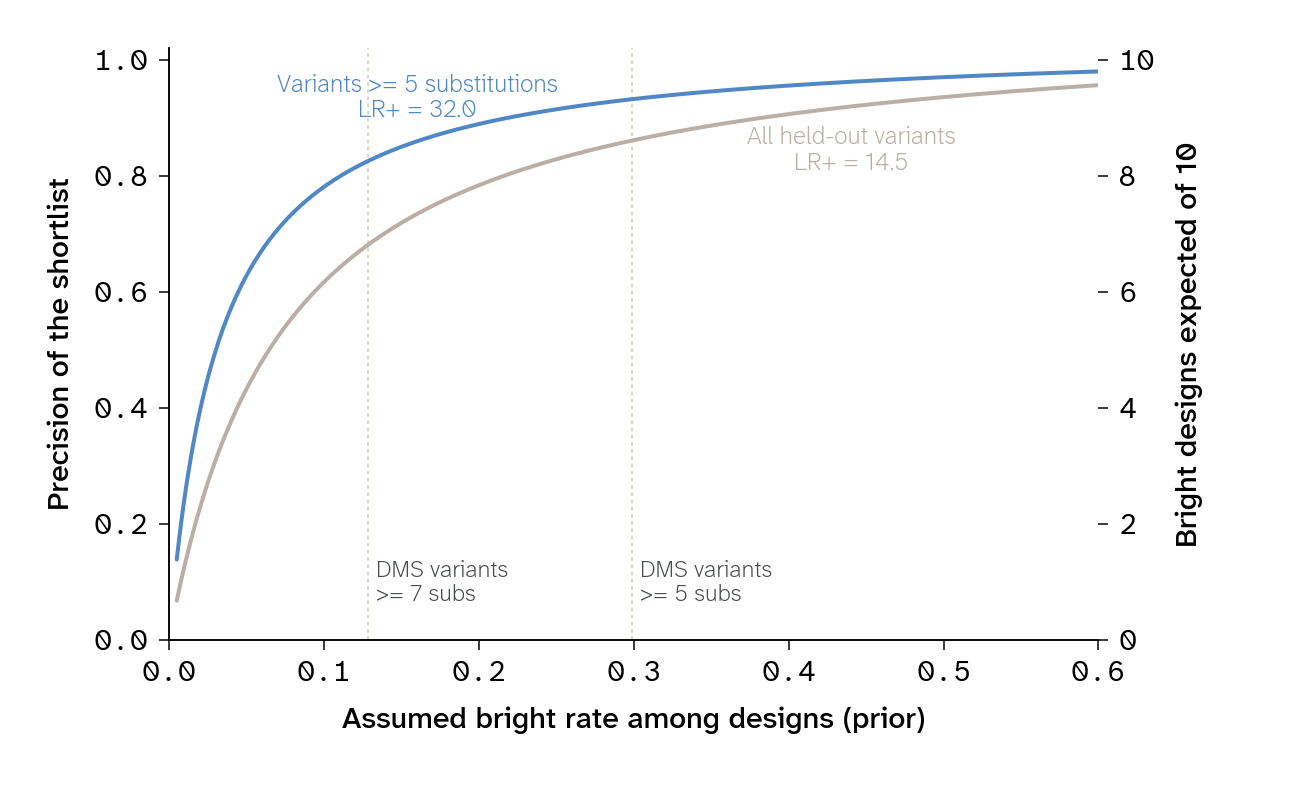

anchor: DMS variants >= 5 subs -> bright rate 0.299
anchor: DMS variants >= 7 subs -> bright rate 0.129

  prior          All held-out variants    Variants >= 5 substitutions
   0.02            0.228 ->  2.3 of 10            0.395 ->  4.0 of 10
   0.05            0.432 ->  4.3 of 10            0.628 ->  6.3 of 10
   0.10            0.617 ->  6.2 of 10            0.781 ->  7.8 of 10
   0.20            0.784 ->  7.8 of 10            0.889 ->  8.9 of 10
   0.30            0.861 ->  8.6 of 10            0.932 ->  9.3 of 10


In [18]:
# LR+ is measured, the prior is not -- so the figure is a curve over the prior with the measured
# ratios as the two lines, and the anchors on the x-axis are prevalences this dataset can actually
# report for variant populations at comparable edit load.
LRS = {
    # (LR+, colour, where to hang the label: prior, vertical placement)
    "All held-out variants": (gate(te, THR_SHORTLIST)["lr_plus"], NEUTRAL, 0.44, "top"),
    "Variants >= 5 substitutions": (gate(te[te.n_mut >= 5], THR_SHORTLIST)["lr_plus"], HIGHLIGHT,
                                    0.16, "bottom"),
}
ANCHORS = [(float(te[te.n_mut >= 5].y.mean()), "DMS variants\n>= 5 subs"),
           (float(te[(te.n_mut >= 7)].y.mean()), "DMS variants\n>= 7 subs")]
N_WELLS = 10
prior = np.linspace(0.005, 0.6, 400)

fig, ax = plt.subplots(figsize=(FLOAT * PX, 400 * PX))
fig.subplots_adjust(left=0.13, right=0.845, bottom=0.20, top=0.94)

for label, (lr, color, at, va) in LRS.items():
    ppv = lr * prior / (lr * prior + (1 - prior))
    ax.plot(prior, ppv, color=color, lw=2, zorder=4)
    j = int(np.argmin(np.abs(prior - at)))
    ax.annotate(f"{label}\nLR+ = {lr:.1f}", xy=(prior[j], ppv[j]),
                xytext=(0, 10 if va == "bottom" else -10), textcoords="offset points",
                ha="center", va=va, **{**ANNOTATION, "fontsize": 12.5, "color": color})
for v, name in ANCHORS:
    ax.axvline(v, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.9, zorder=2)
    ax.annotate(name, xy=(v, 0.06), xytext=(4, 0), textcoords="offset points", ha="left",
                va="bottom", **{**ANNOTATION, "fontsize": 12})
ax.set(xlim=(0, 0.6), ylim=(0, 1.02),
       xlabel="Assumed bright rate among designs (prior)",
       ylabel="Precision of the shortlist")
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)

wells = ax.twinx()
wells.set_ylim(0, 1.02 * N_WELLS)
wells.set_ylabel(f"Bright designs expected of {N_WELLS}")
wells.spines["top"].set_visible(False)
apc.mpl.style_plot(wells, monospaced_axes="y")

fig.savefig(f"{FIGDIR}/brightness_expected_yield.svg")
fig.savefig(f"{FIGDIR}/brightness_expected_yield.png", dpi=200)
plt.show()

for v, name in ANCHORS:
    print(f"anchor: {name.replace(chr(10), ' ')} -> bright rate {v:.3f}")
print()
print(f"{'prior':>7} " + " ".join(f"{k:>30}" for k in LRS))
for p in (0.02, 0.05, 0.10, 0.20, 0.30):
    cells = []
    for lr, *_ in LRS.values():
        ppv = lr * p / (lr * p + (1 - p))
        cells.append(f"{ppv:.3f} -> {ppv * N_WELLS:4.1f} of {N_WELLS}")
    print(f"{p:7.2f} " + " ".join(f"{c:>30}" for c in cells))

**Figure 7. What the shortlist is worth depends on a prior nobody has measured; the classifier
supplies only the multiplier.** Precision of a `logit > 0.5` shortlist as a function of the assumed
bright rate among candidate designs, for the positive likelihood ratio measured over all held-out
variants (Chateau, LR+ = 14.5) and over held-out variants carrying ≥ 5 substitutions (Aegean,
LR+ = 32.0). The right axis converts precision to designs expected to light up out of the 10 a
strategy actually gets. Dashed rules mark the bright rates this dataset can report for variant
populations at comparable edit load (30% at ≥ 5 substitutions, 13% at ≥ 7).

The classifier's contribution is a factor of 15-32 on the odds. What that is worth swings by a
factor of two over any plausible prior: at a 5% design bright rate the shortlist is 43-63% precise
(4-6 wells of 10), at 10% it is 62-78%, and at the 30% that DMS variants of ≥ 5 substitutions
achieve it is 86-93%. The likelihood ratio being *higher* in the matched stratum (32 vs 15) is not
a fluke of noise: at higher edit load the model's false-positive rate drops (2.7% vs 6.5%) faster
than its true-positive rate does, because dim variants at high load are easy. That is the ratio a design campaign should quote.

The honest summary of this notebook is that the classifier is strong where it can be measured — a
factor of 15-32 on the odds, and 0.82-0.91 precision in the distance band the accepted designs
occupy — and that the one input which moves the answer most, the design pool's true bright rate, is
not measurable from DMS data at all. The wet-lab batch is what supplies it: 10 designs per strategy, gated at `logit > 0.5`, whose
observed bright fraction is a direct estimate of PPV at the campaign's own operating point, and
which combined with the measured LR+ inverts to the prior for the next round.

## 8. Metric card

Everything above, in the form it should be quoted in — and what each number does not cover.

| Metric | Question it answers | Value (deployed `cnn-max-d2` @ 40k, held-out test) | Read with |
|---|---|---|---|
| Val / test AUROC | Which architecture to deploy | 0.982 / 0.981 | Architecture choice only. Two thirds of variants are scored \|logit\| > 4; this number is about them, and Figure 3 shows how little of the curve the campaign uses. |
| Precision at `logit > 0` | How often `is_bright` is right | 0.966 | Prevalence 0.70. Per scaffold 0.955-0.974; avGFP 0.959. |
| Precision at `logit > 0.5` | How often a shortlist-eligible call is right | 0.971 | +0.5 pp over the boundary for -1.2 pp recall: the stricter bar is nearly a no-op on DMS data. |
| Precision by cloud distance | Precision inside the ID gate | 0.985 / 0.961 / 0.906 / 0.839 / 0.821 at pct 0-50 / 50-90 / 90-95 / 95-98 / 98-99 | Measured on all 97,499 never-fitted variants, not the test split. Accepted designs sit at pct 90-98, where precision is 0.82-0.91, not the 0.97 the aggregate suggests. |
| LR+ at `logit > 0.5` | The transportable multiplier | 14.5 overall, 32.0 at ≥ 5 subs; 10.6 → 51.3 across cloud-distance strata | The only quantity that survives the prevalence change from DMS variants to designs, and what Figure 4 reads against an assumed prior — but it is read at a fixed bar, and the bar drifts: the rise across strata is recall collapsing 0.96 → 0.61, not sharper discrimination. |
| LR+ at matched recall 0.90 | Whether discrimination itself degrades out of distribution | 21.8 / 18.0 / 15.1 / 12.4 / 9.1 at pct 0-50 / 50-90 / 90-95 / 95-98 / 98-99 | The fixed-bar row read with the threshold's drift removed. Falls by ~2x into the accepted band; hitting recall 0.90 there needs `logit` -0.6 to -1.8, not +0.5. |
| LR+ at a raised bar | What the deployed threshold leaves unclaimed | 54.7 and 49.6 at `logit > 2` in pct 90-95 / 95-98, against 23.2 and 25.9 at `logit > 0.5` | Recall is nearly free here (thousands of designs, ten wells), so this is a ~2x return for a 12-pp recall cost and a fifth of the pool. Stricter still keeps climbing but rests on <10 false positives. |
| Expected shortlist yield | What 10 wells should return | 4-6 of 10 at a 5% prior, 8-9 at 20% | The prior is unmeasured; see Section 7. |

**What is still missing, in rough order of value per unit of compute.**

1. **Prospective wet-lab precision.** 40 shortlisted designs, gated at `logit > 0.5`, measured
   bright/dim. This is the only number that tests the classifier on the population it is deployed
   on, and it also pins Figure 7's prior. Everything else here is a proxy for it.
2. **A threshold chosen rather than inherited.** `logit > 0.5` came from the shortlist code, not from
   an analysis; Figure 6B says `logit > 2` roughly doubles the multiplier where the designs sit, at a
   recall cost the design pool can absorb. Costs nothing but a decision — and it is the cheapest
   improvement on this list.
3. **Recalibration on the validation split.** A single logit offset (or Platt scaling) fitted on
   held-out data, so that the shortlist bar means the probability the code comments claim and
   `lam_bright` scales a calibrated score. Costs one scoring pass, no retraining.
4. **Leave-one-scaffold-out AUROC and precision.** Four refits, each holding out one ortholog
   entirely. The current per-scaffold numbers are within-scaffold generalization — every scaffold's
   wild type and most of its mutational neighbourhood are in training — so they say nothing about
   transfer to a scaffold the model has never seen. EGFP is avGFP-derived, so avGFP-held-out is the
   directly relevant case. ~4 x 12 min on one GPU at the 40k data size.
5. **Seed replicates for the top group.** The three-way tie in Figure 2 was settled by a bootstrap
   over variants at a single seed; 3-5 seeds per top configuration would separate architecture
   variance from initialization variance and cost ~1 GPU-hour.
6. **A high-load DMS slice, if one exists.** Every limitation in Sections 4-6 traces back to the
   same gap: these libraries are built from a handful of substitutions, and the campaign designs at
   ten — the matched stratum Figure 3 leans on is variants with ≥ 5 substitutions, and the distance
   strata the designs occupy are thin for the same reason. A multi-mutant brightness dataset (or a
   targeted pocket library) would turn precision at 7-14 substitutions into a real estimate. This is the highest-value
   *data* addition, as opposed to compute.